In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import matplotlib.cm as cm
import re

In [ ]:
os.chdir("/home/iwatts/catastrophic-forgetting")
print(os.getcwd())

/home/iwatts/catastrophic-forgetting


## Globals

In [ ]:
results_dir = "results/"
RESULTS = dict() 
PROJECT_NAME = "ModelEvaluation"

In [ ]:
CHECKPOINT_MAP = {
    20 : {
        15000: 4,
        30000: 8,
        55000: 16,
        110000: 32,
        220000: 64,
        # 445000: 128, 
        # 890000: 256 
    },
    60: {
        35000: 12,
        40000: 12,
        45000: 12,
        75000: 24,
        85000: 24,
        90000: 24,
        155000: 48,
        165000: 48,
        175000: 48,
        180000: 48,
        305000: 96,
        335000: 96,
        350000: 96, 
        365000: 96,
        610000: 192,
        670000: 192,
        700000: 192,
        730000: 192,
        # 1330000: 384
    },
    150: {
        57000: 15,
        114000: 30,
        228000: 60,
        457000: 120
    }
}

OPTIM_MAP = {
    "adamw": "AdamW",
    "sam": "SAM"
}

PERTURBATIONS = sorted([0.009, 0.013, 0.017, 0.02, 0.025, 0.03, 0.05, 0.075, 0.1])

BITS = [4, 8]

PT_LR = {
    20 : {
        4: 3e-3,
        8: 3e-3,
        16: 3e-3,
        32: 1e-3,
        64: 1e-3,
    },
    60: {
        12: 1e-3,
        24: 1e-3,
        48: 6e-4,
        96: 6e-4,
        192: 3e-4,
    },
    150: {
        15: 1e-3,
        30: 1e-3,
        60: 6e-4,
        120: 6e-4,
    },
    300: {
        15: 1e-3,
        30: 1e-3,
        60: 1e-3,
        120: 1e-3,
    }
}

In [ ]:
TASKNAME_MAP = {
    # "c4_val": "eval-data_perplexity_v3_small_gptneox20b_c4_en_val_part-0-00000",
    # "starcoder_val": "preprocessed_starcoder_v0_decontaminated_doc_only_gpt-neox-olmo-dolma-v1_5_part-00-00001",
    # "tinygsm_val": "preprocessed_tinyGSM_mind_dolma2-tokenizer_part-01-00000-2M",
    # "starcoder_val": "preprocessed_starcoder_v1-decon-100_to_20k-2star-top_token_030_allenai_dolma2-tokenizer_part-010-00000-20M",
    "starcoder_val": "input_ids-starcoder",
    # "starcoder2_val": "preprocessed_starcoder_v1-decon-100_to_20k-2star-top_token_030_allenai_dolma2-tokenizer_part-010-00000-20M",
    # "starcoder3_val": "preprocessed_starcoder_v1-decon-100_to_20k-2star-top_token_030_allenai_dolma2-tokenizer_part-010-00000-20M",
    # "dclm_val": "preprocessed_dclm_text_openhermes_reddit_eli5_vs_rw_v2_bigram_200k_train_allenai_dolma2-tokenizer_part-187-00004-20M",
    "dclm_val": "dclm-20m",
    "dclm_train": "dclm-train-20m",
    "musicpile_val": "input_ids-musicpile",
    "tulu_val": "input_ids-tulu",
    # "c4_val": "eval-data_perplexity_v3_small_dolma2-tokenizer_c4_en_val_part-0-00000",
}

## Parse Evalaution JSONs

In [ ]:
for project in os.listdir(results_dir):
    if project != PROJECT_NAME:
        continue

    project_results = list()
    project_dir = os.path.join(results_dir, project)
    for file in os.listdir(project_dir):

        fname = os.path.join(project_dir, file)
        with open(fname, 'r') as f:
            data = json.load(f)

        fname = fname.removesuffix("-eval.json")
        if "OLMo2" not in fname:
            continue

        # Parse model size (e.g., "OLMo-20m-" gives 20)
        size_match = re.search(r'OLMo2-(\d+)m-', fname)
        if size_match:
            size = int(size_match.group(1))
        else:
            size = None  # Could be "unknown" if not found

        # Check if this is a 'perturbed' run (look for "_perturbed_<value>" in fname)
        perturbation = None
        pt_lrs = None
        # Support both _perturbed_1e-2 and _perturbed_1_50e-2
        perturbed_match = re.search(r'_perturbed_([0-9_\.eE\-\+]+)', fname)
        if perturbed_match:
            pert_val_str = perturbed_match.group(1)
            # Handle values like "1_50e-2": convert to float by replacing first "_" with "."
            if "_" in pert_val_str:
                # Try to parse forms like "1_50e-2"
                # This is to match prompts like "OLMo-20m-tk300B-adamw-lr3e-4-wd1e-1-bs256-anneal-ckpt15000_perturbed_1_50e-2-eval.json"
                pert_val_str_parts = pert_val_str.split("_", 1)
                if len(pert_val_str_parts) == 2:
                    new_val_str = pert_val_str_parts[0] + "." + pert_val_str_parts[1]
                else:
                    new_val_str = pert_val_str.replace("_", ".")   # fallback
                try:
                    perturbation = float(new_val_str)
                except Exception:
                    raise ValueError(f"Could not convert perturbation value: {pert_val_str!r} became {new_val_str!r}")
            else:
                try:
                    perturbation = float(pert_val_str)
                except Exception:
                    raise ValueError(f"Could not convert perturbation value: {pert_val_str!r}")

        # Run type logic: cpt > perturbed > pretrain
        is_cpt = 'CPT' in fname
        if perturbation is not None:
            run_type = "perturbed"
        elif is_cpt:
            run_type = "cpt"
        elif "quant" in fname:
            run_type = "quant"
        else:
            run_type = "pretrain"

        if "quant" in fname:
            # Parse quantization bit value if present (e.g., '-quant-8bit')
            quant_bit = None
            quant_match = re.search(r'-quant-(\d+)bit', fname)
            if quant_match:
                try:
                    quant_bit = int(quant_match.group(1))
                except Exception:
                    raise ValueError(f"Could not parse quantization bit value from filename: {fname!r}")

        # If "anneal" is present, get ckpt<> value as token, else get tk<>B
        if "anneal" in fname:
            pt_lrs = "wsd"
            # Check for 'steps' and extract the int value
            steps_match = re.search(r'steps(\d+)', fname)
            percent_match = re.search(r'percent(\d+)', fname)
            anneal_steps = None
            anneal_percent = None
            if steps_match:
                anneal_steps = int(steps_match.group(1))
            if percent_match:
                anneal_percent = int(percent_match.group(1))
            # Try to find 'ckpt<digits>' (e.g. ckpt55000)
            ckpt_match = re.search(r'ckpt(\d+)', fname)
            if ckpt_match:
                try:
                    token = CHECKPOINT_MAP[size][int(ckpt_match.group(1))]
                except:
                    print(f"Skipping ckpt {ckpt_match.group(1)}")
                    continue
            else:
                raise ValueError("Unable to find ckpt value in filename with anneal: %s" % fname)

        else:
            token_match = re.search(r'tk(\d+)B', fname)
            token = token_match.group(1) if token_match else "unknown"
            pt_lrs = "cosine"
            if token != "unknown":
                try:
                    token = int(token)
                except Exception:
                    raise ValueError("Unable to convert tk token to Int: %s" % fname)
            else:
                raise ValueError("Unable to Parse tk<B> for token: %s" % fname)

        # Get the optimizer (can be sam, adamw, lionw, sam_adamw, sam_sgd)
        optimizer_match = re.search(r'tk\d+B-([a-zA-Z0-9_]+)-lr', fname)
        optimizer_raw = optimizer_match.group(1) if optimizer_match else "unknown"

        # Handle sam_adamw and sam_sgd specially
        if optimizer_raw in ("sam_adamw", "sam_sgd"):
            optimizer = "sam"
            base_optimizer = optimizer_raw.split("_")[1]

            # Properly extract rho after "-rho", e.g.: "...-bs256-rho1e-1-"
            rho_match = re.search(r'-rho([0-9eE\+\-\.]+)', fname)
            if not rho_match:
                # fallback: some files may omit '-rho', to maintain old behavior if necessary
                rho_match = re.search(r'-bs256-([0-9eE\+\-\.]+)-', fname)
            rho = rho_match.group(1) if rho_match else "unknown"

            if rho != "unknown":
                rho_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', rho)
                rho_cleaned = rho_cleaned.rstrip('-')
                try:
                    rho_val = float(rho_cleaned)
                except Exception:
                    raise ValueError(f"Unable to convert rho to float: {rho_cleaned!r}")
            else:
                raise ValueError("Unable to Parse rho")
        else:
            optimizer = optimizer_raw
            base_optimizer = None
            rho_val = None

        # Always get pretrain_lr (after the optimizer)
        pretrain_lr_match = re.search(rf'{optimizer_raw}-lr([0-9eE\+\-\.]+)', fname)
        pretrain_lr = pretrain_lr_match.group(1) if pretrain_lr_match else "unknown"
        if pretrain_lr != "unknown":
            pretrain_lr_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', pretrain_lr)
            pretrain_lr_cleaned = pretrain_lr_cleaned.rstrip('-')
            try:
                pretrain_lr = float(pretrain_lr_cleaned)
            except Exception:
                raise ValueError(f"Unable to convert to Float: {pretrain_lr_cleaned!r}")
        else:
            raise ValueError("Unable to Parse pretrain_lr in %s" % fname)

        # Always get pretrain_wd (right after pretrain_lr)
        pretrain_wd_match = re.search(rf'{optimizer_raw}-lr[0-9eE\+\-\.]+-wd([0-9eE\+\-\.]+)', fname)
        pretrain_wd = pretrain_wd_match.group(1) if pretrain_wd_match else "unknown"
        if pretrain_wd != "unknown":
            pretrain_wd_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', pretrain_wd)
            pretrain_wd_cleaned = pretrain_wd_cleaned.rstrip('-')
            try:
                pretrain_wd = float(pretrain_wd_cleaned)
            except Exception:
                raise ValueError(f"Unable to convert to Float: {pretrain_wd_cleaned!r}")
        else:
            raise ValueError("Unable to Parse pretrain_wd in %s" % fname)

        # Default cpt values
        cpt_lr, cpt_wd, cpt_dataset = None, None, None
        if is_cpt:
            # Extract cpt_dataset and cpt_tokens (tk{5,10,20}M). Default cpt_tokens is 10 if not present
            cpt_dataset_match = re.search(r'CPT-([a-zA-Z0-9_]+)-tk([0-9]+)M-lr', fname)
            if cpt_dataset_match:
                cpt_dataset = cpt_dataset_match.group(1)
                cpt_tokens = int(cpt_dataset_match.group(2))
            else:
                # Fallback to cpt_dataset only (for compatibility)
                cpt_dataset_match = re.search(r'CPT-([a-zA-Z0-9_]+)-lr', fname)
                cpt_dataset = cpt_dataset_match.group(1) if cpt_dataset_match else "unknown"
                cpt_tokens = 10  # default

            # Find correct learning rate key for CPT dataset with tk tokens present
            cpt_lr_match = re.search(rf'CPT-{cpt_dataset}-tk{cpt_tokens}M-lr([0-9eE\+\-\.]+)', fname)
            if not cpt_lr_match:
                # Fallback in case format is old (no tk tokens)
                cpt_lr_match = re.search(rf'CPT-{cpt_dataset}-lr([0-9eE\+\-\.]+)', fname)
            cpt_lr = cpt_lr_match.group(1) if cpt_lr_match else "unknown"
            if cpt_lr != "unknown":
                cpt_lr_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', cpt_lr)
                cpt_lr_cleaned = cpt_lr_cleaned.rstrip('-')
                try:
                    cpt_lr = float(cpt_lr_cleaned)
                except Exception:
                    raise ValueError(f"Unable to convert to Float: {cpt_lr_cleaned!r}")
            else:
                raise ValueError("Unable to Parse")

            cpt_wd_match = re.search(rf'CPT-{cpt_dataset}-tk{cpt_tokens}M-lr[0-9eE\+\-\.]+-wd([0-9eE\+\-\.]+)', fname)
            if not cpt_wd_match:
                # Fallback in case format is old (no tk tokens)
                cpt_wd_match = re.search(rf'CPT-{cpt_dataset}-lr[0-9eE\+\-\.]+-wd([0-9eE\+\-\.]+)', fname)
            cpt_wd = cpt_wd_match.group(1) if cpt_wd_match else "unknown"
            if cpt_wd != "unknown":
                cpt_wd_cleaned = re.sub(r'[^0-9eE\+\-\.]+$', '', cpt_wd)
                cpt_wd_cleaned = cpt_wd_cleaned.rstrip('-')
                try:
                    cpt_wd = float(cpt_wd_cleaned)
                except Exception:
                    raise ValueError(f"Unable to convert to Float: {cpt_wd_cleaned!r}")
            else:
                raise ValueError("Unable to Parse")
        if "hf" in fname:
            model_type = "hf"
        else:
            model_type = "olmo"

        run_info = {
            "run_type": run_type,
            "model_type": model_type,
            "token": token,
            "optimizer": optimizer,
            "pretrain_lr": pretrain_lr,
            "pretrain_wd": pretrain_wd,
            "pretrain_lrs": pt_lrs,
            # "c4_val": data[TASKNAME_MAP["c4_val"]],
            "dclm_val": data[TASKNAME_MAP["dclm_val"]],
            "size": size,
        }
        if run_info["run_type"] == "pretrain":
            run_info["dclm_train"] = data.get(TASKNAME_MAP["dclm_train"], None)
        if perturbation is not None:
            run_info["perturbation"] = perturbation
        if run_info["run_type"] == "quant":
            run_info["quant_bit"] = quant_bit
        if base_optimizer is not None:
            run_info["base_optimizer"] = base_optimizer
        if rho_val is not None:
            run_info["rho"] = rho_val
        if is_cpt:
            run_info["cpt_lr"] = cpt_lr
            run_info["cpt_wd"] = cpt_wd
            run_info["cpt_dataset"] = cpt_dataset
            run_info["cpt_tokens"] = cpt_tokens
            run_info[f"{cpt_dataset}_val"] = data[TASKNAME_MAP[f"{cpt_dataset}_val"]]
        if pt_lrs == "wsd":
            run_info["anneal_steps"] = anneal_steps
            run_info["anneal_percent"] = anneal_percent
        
        project_results.append(run_info)

    RESULTS[project] = project_results


In [ ]:
[r for r in RESULTS[PROJECT_NAME] if r.get('cpt_tokens') == 20]

[{'run_type': 'cpt',
  'model_type': 'olmo',
  'token': 96,
  'optimizer': 'sam',
  'pretrain_lr': 0.0006,
  'pretrain_wd': 0.1,
  'pretrain_lrs': 'cosine',
  'dclm_val': 5.7052684709970345,
  'size': 60,
  'base_optimizer': 'adamw',
  'rho': 0.05,
  'cpt_lr': 0.001,
  'cpt_wd': 0.1,
  'cpt_dataset': 'starcoder',
  'cpt_tokens': 20,
  'starcoder_val': 2.3852160096700725},
 {'run_type': 'cpt',
  'model_type': 'olmo',
  'token': 192,
  'optimizer': 'sam',
  'pretrain_lr': 0.0003,
  'pretrain_wd': 0.1,
  'pretrain_lrs': 'cosine',
  'dclm_val': 3.7618233802119145,
  'size': 60,
  'base_optimizer': 'adamw',
  'rho': 0.05,
  'cpt_lr': 0.0002,
  'cpt_wd': 0.1,
  'cpt_dataset': 'starcoder',
  'cpt_tokens': 20,
  'starcoder_val': 2.414048655668084},
 {'run_type': 'cpt',
  'model_type': 'olmo',
  'token': 192,
  'optimizer': 'sam',
  'pretrain_lr': 0.0003,
  'pretrain_wd': 0.1,
  'pretrain_lrs': 'cosine',
  'dclm_val': 4.789845378129344,
  'size': 60,
  'base_optimizer': 'adamw',
  'rho': 0.05,


## Plotting

In [ ]:
SIZE = [20, 60, 150] #, 150, 300]
CPT_DATASET = ["starcoder", "musicpile", "tulu"]
OPTIM = ['adamw', 'sam']
SAVE = False
# RHO = [1e-2, 2e-2, 5e-2, 7e-2, 1e-1, 2e-1, 4e-1, 1]
RHO = [5e-2]
VERBOSE = False

In [ ]:
TICKS_FONTSIZE=14
TITLE_FONTSIZE=16
AXIS_FONTSIZE=16
LEGEND_FONTSIZE=12

In [ ]:
SKIP_CPT_LR = {
    "starcoder": [8e-3],
    "musicpile": [8e-3],
    "tulu": [2e-3]
}

In [ ]:
ANNEAL_CONFIG = {
    "steps" : [1000, 2000, 4000],
    "percent" : [5, 10, 20]
}

### Helper Functions

In [ ]:
np.unique(list(CHECKPOINT_MAP[150].values()))

array([ 15,  30,  60, 120])

In [ ]:
def get_run_info(size, optim, cpt_dataset=None, cpt_tokens=10, project_name="ModelEvaluation", rho=5e-2, perturb=False, quantized=False, pt_lr="adapt", anneal=False, anneal_steps=None, anneal_percent=None, model_type="olmo"):

    run_info = dict()
    run_info["pretrain"] = dict()
    
    tokens_list = np.unique(list(CHECKPOINT_MAP[size].values()))
    all_runs = [r for r in RESULTS[project_name] if r.get("token") in tokens_list and r.get("size") == size and r.get("optimizer") == optim and r.get("model_type") == model_type]

    if pt_lr == "adapt":
        all_runs = [r for r in all_runs if r.get("pretrain_lr") == PT_LR[size][r["token"]]]
    else:
        all_runs = [r for r in all_runs if r.get("pretrain_lr") == pt_lr]

    if anneal:
        assert anneal_steps is not None or anneal_percent is not None
        all_runs = [r for r in all_runs if r.get("pretrain_lrs") == "wsd"]
        if anneal_steps is not None:
            all_runs = [r for r in all_runs if r.get("anneal_steps") == anneal_steps]
        if anneal_percent is not None:
            all_runs = [r for r in all_runs if r.get("anneal_percent") == anneal_percent]  

    else:
        all_runs = [r for r in all_runs if r.get("pretrain_lrs") == "cosine"]

    if optim == "sam":
        all_runs = [r for r in all_runs if r.get("rho") == rho]

    if len(all_runs) == 0:
        return None

    pretrain_runs = [r for r in all_runs if r.get("run_type") == "pretrain"]
    for t in tokens_list:
        run = [r for r in pretrain_runs if r.get("token") == t]
        if len(run) == 0:
            if VERBOSE:
                print(f"Missing Run: Optim {OPTIM_MAP[optim]} | Token {t}B | Size {size}M")
            continue
        assert len(run) == 1, print(run)
        run = run[0]

        run_info["pretrain"][t] = {
            "token" : t,
            "multiplier" : (t * 1000) / size,
            # "c4": run["c4_val"],
            "dclm_val": run["dclm_val"],
            "dclm_train": run["dclm_train"]
        }

    if perturb:
        run_info["perturbed"] = dict()
        perturbed_runs = [r for r in all_runs if r.get("run_type") == "perturbed"]

        for perturbation in PERTURBATIONS:
            run_info["perturbed"][perturbation] = dict()
            run_perturbed = [r for r in perturbed_runs if r.get("perturbation") == perturbation]

            for t in tokens_list:
                # run_pt = [r for r in pretrain_runs if r.get("token") == t]
                # assert len(run_pt) == 1, print(run_pt)
                # run_pt = run_pt[0]
                run_pert = [r for r in run_perturbed if r.get("token") == t]
                assert len(run_pert) == 1, print(run_pert)
                run_pert = run_pert[0]

                run_info["perturbed"][perturbation][t] = {
                    "token" : t,
                    "multiplier" : (t * 1000) / size,
                    "perturbed" : perturbation,
                    "dclm_perturbed" : run_pert["dclm_val"],
                    # "dclm" : run_pt["dclm_val"]
                }
    
    if quantized:
        run_info["quantized"] = dict()
        quantized_runs = [r for r in all_runs if r.get("run_type") == "quant"]

        for bit in BITS:
            run_info["quantized"][bit] = dict()
            run_quantized = [r for r in quantized_runs if r.get("quant_bit") == bit]

            for t in tokens_list:
                run_quant = [r for r in run_quantized if r.get("token") == t]
                assert len(run_quant) == 1, print(run_quant)
                run_quant = run_quant[0]

                run_info["quantized"][bit][t] = {
                    "token" : t,
                    "multiplier" : (t * 1000) / size,
                    "quant_bit" : bit,
                    "dclm_quant" : run_quant["dclm_val"],
                    # "dclm" : run_pt["dclm_val"]
                }

    if cpt_dataset is not None:

        run_info["cpt"] = dict()
        cpt_runs = [r for r in all_runs if r.get("run_type") == "cpt" and r.get("cpt_dataset") == cpt_dataset and r.get("cpt_tokens") == cpt_tokens]
        cpt_lrs = sorted(list(set([r.get("cpt_lr") for r in cpt_runs])))
        cpt_lrs = [cpt_lr for cpt_lr in cpt_lrs if cpt_lr not in SKIP_CPT_LR[cpt_dataset]]

        for cpt_lr in cpt_lrs:
            run_info["cpt"][cpt_lr] = dict()
            for t in tokens_list:
                run = [r for r in cpt_runs if r.get("cpt_lr") == cpt_lr and r.get("token") == t]
                if len(run) == 0:
                    if VERBOSE:
                        print(f"Missing Run: Optim {OPTIM_MAP[optim]} | Token {t}B | Size {size}M | CPT dataset {cpt_dataset} | CPT LR {cpt_lr}")
                    continue
                assert len(run) == 1
                run = run[0]

                run_info["cpt"][cpt_lr][t] = {
                    "token": t,
                    "multiplier" : (t * 1000) / size,
                    "cpt_lr": cpt_lr,
                    # "c4": run["c4_val"],
                    "dclm_val": run["dclm_val"],
                    cpt_dataset: run[f"{cpt_dataset}_val"]
                }

    return run_info



In [ ]:
def complete_the_square(A, B, C):
    """
    'complete the square' for quadratics A x^2 + B x + C.

    A, B, C can be scalars.

    Returns:
        a, b, c such that:
            A x^2 + B x + C = a * (x - b)**2 + c
    """

    if A == 0:
        raise ValueError("A must be nonzero for quadratics.")

    a = A
    b = -B / (2 * A)
    c = C - A * b**2   # equivalently: C - B**2 / (4*A)

    return a, b, c

In [ ]:
def get_pplx(x, coeffs, log=True):
    if log:
        x = np.log(x)
    return coeffs[0] * (x - coeffs[1])**2 + coeffs[2]

In [ ]:
def fit_polynomial_interpolate(x, y, test_x, degree=2):

    coeffs = np.polyfit(x, y, degree)
    test_y = np.zeros_like(test_x)

    n = len(coeffs)
    for k in range(n):
        test_y += (coeffs[k] * test_x**(n-k-1))
    
    return test_y

## Pretrain Plots

In [54]:
def make_pretrain_plots():
    n_sizes = len(SIZE)
    fig, axs = plt.subplots(1, n_sizes, figsize=(6*n_sizes, 4), sharex=True)

    # To handle the case where axs is not iterable if n_sizes == 1
    if n_sizes == 1:
        axs = [axs]

    plot_handles = []
    plot_labels = []

    for i, (size, ax) in enumerate(zip(SIZE, axs)):
        for j, optim in enumerate(OPTIM):
            if optim == "adamw":
                run_info = get_run_info(size, optim)
                if run_info is None:
                    continue 
                x = [r["multiplier"] for r in run_info["pretrain"].values()]
                y = [r["dclm_val"] for r in run_info["pretrain"].values()]
                # y2 = [r["dclm_train"] for r in run_info["pretrain"].values()]
                handle, = ax.plot(
                    x, y,
                    marker="o",
                    label=f"{OPTIM_MAP[optim]} Val",
                    color="blue",
                )
                # handle2, = ax.plot(
                #     x, y2,
                #     marker="o",
                #     label=f"{OPTIM_MAP[optim]} Train",
                #     color="blue",
                #     linestyle="--"
                # )
                if i == 0:
                    plot_handles.append(handle)
                    plot_labels.append(f"{OPTIM_MAP[optim]} Val")
                    # plot_handles.append(handle2)
                    # plot_labels.append(f"{OPTIM_MAP[optim]} Train")
            elif optim == "sam":
                for rho in RHO:
                    run_info = get_run_info(size, optim, rho=rho)
                    if run_info is None:
                        continue 
                    x = [r["multiplier"] for r in run_info["pretrain"].values()]
                    y = [r["dclm_val"] for r in run_info["pretrain"].values()]
                    # y2 = [r["dclm_train"] for r in run_info["pretrain"].values()]
                    handle, = ax.plot(
                        x, y,
                        marker="o",
                        label=f"{OPTIM_MAP[optim]} Val (rho={rho})",
                        color="orange"
                    )
                    # handle2, = ax.plot(
                    #     x, y2,
                    #     marker="o",
                    #     label=f"{OPTIM_MAP[optim]} Train (rho={rho})",
                    #     color="orange",
                    #     linestyle="--"
                    # )
                    if i == 0:
                        plot_handles.append(handle)
                        plot_labels.append(f"{OPTIM_MAP[optim]} Val (rho={rho})")
                        # plot_handles.append(handle2)
                        # plot_labels.append(f"{OPTIM_MAP[optim]} Train (rho={rho})")

        ax.set_xlabel("Tokens / Param", fontsize=AXIS_FONTSIZE)
        if i == 0:
            ax.set_ylabel("DCLM PPLX", fontsize=AXIS_FONTSIZE)
        ax.set_xscale('log')
        ax.set_title(f"OLMo-{size}M", fontsize=TITLE_FONTSIZE)
        ax.grid(True)
        ax.tick_params(axis='x', labelsize=TICKS_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICKS_FONTSIZE)

    # Only show legend on the last axis (or can do fig-wide)
    axs[2].legend(plot_handles, plot_labels, fontsize=LEGEND_FONTSIZE)
    plt.suptitle(f"Pretrain DCLM PPLX vs Tokens", fontsize=TITLE_FONTSIZE)

    plt.tight_layout()

    if True:
        os.makedirs(os.path.join(results_dir, "plots/pretrain"), exist_ok=True)
        plt.savefig(os.path.join(results_dir, f"plots/pretrain/optim_allsize_pt_pplx.png"), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

make_pretrain_plots()


steps 1000
{'pretrain': {np.int64(12): {'token': np.int64(12), 'multiplier': np.float64(200.0), 'dclm': 3.555335901724212}, np.int64(24): {'token': np.int64(24), 'multiplier': np.float64(400.0), 'dclm': 3.5114310179692247}, np.int64(96): {'token': np.int64(96), 'multiplier': np.float64(1600.0), 'dclm': 3.454647304908088}, np.int64(192): {'token': np.int64(192), 'multiplier': np.float64(3200.0), 'dclm': 3.4363091100277168}}}
steps 2000
{'pretrain': {np.int64(12): {'token': np.int64(12), 'multiplier': np.float64(200.0), 'dclm': 3.5465661769703987}, np.int64(24): {'token': np.int64(24), 'multiplier': np.float64(400.0), 'dclm': 3.5031710437668635}, np.int64(48): {'token': np.int64(48), 'multiplier': np.float64(800.0), 'dclm': 3.4709038707095514}, np.int64(96): {'token': np.int64(96), 'multiplier': np.float64(1600.0), 'dclm': 3.446378854023652}, np.int64(192): {'token': np.int64(192), 'multiplier': np.float64(3200.0), 'dclm': 3.4281808736575856}}}
steps 4000
{'pretrain': {np.int64(12): {'to

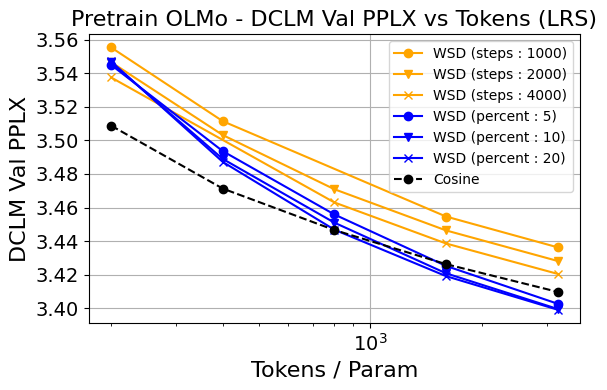

In [18]:
def make_pretrain_plots():

    plt.figure(figsize=(6,4))
    optim = "adamw"
    size = 60

    # Plot data
    for pt_lrs in ["wsd", "cosine"]:
        if pt_lrs == "cosine":
            run_info = get_run_info(size, optim, anneal=False)

            x = [r["multiplier"] for r in run_info["pretrain"].values()]
            y = [r["dclm"] for r in run_info["pretrain"].values()]
            plt.plot(
                x, y,
                marker = "o",
                label="Cosine",
                color="black",
                linestyle="--"
            )
        elif pt_lrs == "wsd":
            markers = ["o", "v", "x"]
            for anneal_type in ANNEAL_CONFIG.keys():
                for i, val in enumerate(ANNEAL_CONFIG[anneal_type]):
                    if anneal_type == "steps":
                        print(anneal_type, val)
                        run_info = get_run_info(size, optim, anneal=True, anneal_steps=val, pt_lr=3e-4)
                        color = "orange"
                        
                    else:
                        run_info = get_run_info(size, optim, anneal=True, anneal_percent=val, pt_lr=3e-4)
                        color = "blue"
                    
                    print(run_info)
                    
                    x = [r["multiplier"] for r in run_info["pretrain"].values()]
                    y = [r["dclm"] for r in run_info["pretrain"].values()]


                    plt.plot(
                        x, y,
                        color=color, 
                        marker=markers[i],
                        label=f"WSD ({anneal_type} : {val})"
                    )


    plt.xlabel("Tokens / Param", fontsize=AXIS_FONTSIZE)
    plt.ylabel("DCLM Val PPLX", fontsize=AXIS_FONTSIZE)
    plt.xscale('log')
    plt.title(f"Pretrain OLMo - DCLM Val PPLX vs Tokens (LRS)", fontsize=TITLE_FONTSIZE)
    plt.grid(True)
    plt.legend()
    plt.xticks(fontsize=TICKS_FONTSIZE)
    plt.yticks(fontsize=TICKS_FONTSIZE)
    plt.tight_layout()

    # Move both legends to the right of the plot, vertically stacked
    # ax = plt.gca()
    # leg1 = ax.legend(handles=color_handles, title='Optimizer', loc='center left', bbox_to_anchor=(1.01, 0.7), frameon=True)
    # leg2 = ax.legend(handles=size_handles, title='Model Size', loc='center left', bbox_to_anchor=(1.01, 0.3), frameon=True)
    # ax.add_artist(leg1)
    # ax.add_artist(leg2)

    if SAVE:
        os.makedirs(os.path.join(results_dir, "plots/pretrain"), exist_ok=True)
        plt.savefig(os.path.join(results_dir, f"plots/pretrain/lrs_pt_pplx.png"), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

make_pretrain_plots()


## CPT Plots

In [6]:
YLIM = {
    "starcoder" : {
        "cpt" : (2.5, 3),
        "pt" : (3, 6.5),
    },
    "musicpile" : {
        "cpt" : (1.55, 1.85),
        "pt" : (3, 6)
    },
    "tulu" : {
        "cpt" : (2.55, 2.85),
        "pt" : (3.4, 3.8)
    }
}

In [7]:
def make_cpt_plots():
    for size in SIZE:
        for cpt_dataset in CPT_DATASET:
            for optim in OPTIM:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                run_info = get_run_info(size, optim, cpt_dataset)

                for cpt_lr in run_info["cpt"].keys():
                    x = [r["multiplier"] for r in run_info["cpt"][cpt_lr].values()]
                    y1 = [r[cpt_dataset] for r in run_info["cpt"][cpt_lr].values()]
                    y2 = [r["dclm"] for r in run_info["cpt"][cpt_lr].values()]

                    ax1.plot(x, y1, label=cpt_lr, marker='o', alpha=0.7)
                    ax2.plot(x, y2, label=cpt_lr, marker='o', alpha=0.7)

                x = [r["multiplier"] for r in run_info["pretrain"].values()]
                y = [r["dclm"] for r in run_info["pretrain"].values()]
                ax2.plot(x, y, label="Base Model", marker="x", linestyle='--', alpha=0.7, color='black')
                
                ax1.set_xscale('log')
                ax1.set_xlabel("Tokens / Param")
                ax1.set_ylabel(f"{cpt_dataset.capitalize()} Val")
                ax1.set_title(f"{cpt_dataset.capitalize()} Val vs Tokens / Param")
                ax1.grid(True)
                # ax1.set_ylim(YLIM[cpt_dataset]["cpt"])

                ax2.set_xscale('log')
                ax2.set_xlabel("Tokens / Param")
                ax2.set_ylabel("DCLM Val")
                ax2.set_title(f"DCLM Val vs Tokens / Param")
                # Put legend outside the plot on the right
                ax2.legend(title="CPT LR", bbox_to_anchor=(1.04, 1), loc="upper left")
                ax2.grid(True)
                # ax2.set_ylim(YLIM[cpt_dataset]["pt"])

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for supertitle
                main_title = f'CPT OLMo {size}M on {cpt_dataset.capitalize()} ({OPTIM_MAP[optim]})'
                plt.suptitle(main_title, fontsize=18)
                
                if SAVE:
                    os.makedirs(os.path.join(results_dir, f"plots/cpt/{cpt_dataset}"), exist_ok=True)
                    plt.savefig(f"results/plots/cpt/{cpt_dataset}/{size}m_{optim}.png")
                    plt.close()
                else:
                    plt.show()

In [ ]:
make_cpt_plots()

### Automatic CPT Plotting

In [14]:
QUAD_COEFF = dict()

#### Get Quad Coeffs

In [15]:
def fit_quadratic():
    for size in SIZE:
        QUAD_COEFF[size] = dict()
        for cpt_dataset in CPT_DATASET:
            QUAD_COEFF[size][cpt_dataset] = dict()
            for optim in OPTIM:
                QUAD_COEFF[size][cpt_dataset][optim] = dict()

                fig, axs = plt.subplots(1, 2, figsize=(15, 6))
                run_info = get_run_info(size, optim, cpt_dataset)
                colors = plt.cm.viridis(np.linspace(0,1,len(run_info["cpt"].keys())))

                for i, run_type in enumerate(["cpt", "pretrain"]):

                    QUAD_COEFF[size][cpt_dataset][optim][run_type] = dict()
                    for j, cpt_lr in enumerate(run_info["cpt"].keys()):
                        x = [r["multiplier"] for r in run_info["cpt"][cpt_lr].values()]
                        if run_type == "cpt":
                            y = [r[cpt_dataset] for r in run_info["cpt"][cpt_lr].values()]
                        else:
                            y = [r["dclm"] for r in run_info["cpt"][cpt_lr].values()]

                        log_x = np.log(x)
                        coeffs = complete_the_square(*np.polyfit(log_x, y, 2))
                        QUAD_COEFF[size][cpt_dataset][optim][run_type][cpt_lr] = coeffs


                        # Check Fit
                        axs[i].plot(x, y, label=cpt_lr, marker='o', alpha=0.7, color=colors[j])
                        x_fit = (np.linspace(min(x), max(x), 100))
                        y_fit = get_pplx(x_fit, coeffs)
                        axs[i].plot(x_fit, y_fit, label=f"{cpt_lr} (fit)", marker='x', alpha=0.7, linestyle = "--", color=colors[j])

                    axs[i].set_xscale('log')
                    axs[i].set_xlabel("Tokens / Param")
                    axs[i].grid(True)
                    if run_type == "cpt":
                        axs[i].set_ylabel(f"{cpt_dataset.capitalize()} Val")
                        axs[i].set_title(f"{cpt_dataset.capitalize()} Val vs Tokens / Param")
                    else:
                        axs[i].set_ylabel("DCLM Val")
                        axs[i].set_title(f"DCLM Val vs Tokens / Param")
                        axs[i].legend(title="CPT LR", bbox_to_anchor=(1.04, 1), loc="upper left")
                    

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for supertitle
                main_title = f'Fitted CPT OLMo {size}M on {cpt_dataset.capitalize()} ({OPTIM_MAP[optim]})'
                plt.suptitle(main_title, fontsize=18)
                if SAVE:
                    os.makedirs(os.path.join(results_dir, f"plots/fitted_cpt/{cpt_dataset}"), exist_ok=True)
                    plt.savefig(f"results/plots/fitted_cpt/{cpt_dataset}/{size}m_{optim}.png")
                    plt.close()
                else:
                    plt.show()
                
                # Create a 2x3 grid for plotting (2 rows: cpt/pretrain, 3 columns: A/B/C)
                fig, axes = plt.subplots(2, 3, figsize=(18, 10))

                for i, run_type in enumerate(["cpt", "pretrain"]):
                    for j, coeff in enumerate(["A", "B", "C"]):
                        ax = axes[i, j]

                        cpt_lrs = list(QUAD_COEFF[size][cpt_dataset][optim][run_type].keys())
                        vals = [QUAD_COEFF[size][cpt_dataset][optim][run_type][lr][j] for lr in cpt_lrs]

                        ax.plot(cpt_lrs, vals, marker="o")
                        ax.set_xlabel("LR")
                        ax.set_ylabel(f"Quadratic {coeff} Coefficient")
                        ax.set_title(f"{run_type.capitalize()} Quadratic {coeff} vs LR")
                        ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
                        ax.grid(True)

                        # Check Fit
                        x_fit = (np.linspace(min(cpt_lrs), max(cpt_lrs), 100))
                        y_fit = fit_polynomial_interpolate(cpt_lrs, vals, x_fit, 3)
                        ax.plot(x_fit, y_fit, label=f"{coeff} (fit)", marker='x', alpha=0.7, linestyle = "--")

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                main_title = f'Quadratic Coeff CPT OLMo {size}M on {cpt_dataset.capitalize()} ({OPTIM_MAP[optim]})'
                plt.suptitle(main_title, fontsize=18)
                if SAVE:
                    os.makedirs(os.path.join(results_dir, f"plots/fitted_cpt/{cpt_dataset}"), exist_ok=True)
                    plt.savefig(f"results/plots/fitted_cpt/{cpt_dataset}/coeffs_{size}m_{optim}.png")
                    plt.close()
                else:
                    plt.show()
                    
                        



In [ ]:
fit_quadratic()

#### Forgetting Plots using Fitted Values

In [25]:
TEST_CPT_LR = np.arange(4e-4, 2.0001e-3, 1e-6)
TEST_PRETRAIN_TOKEN_MULTIPLIER = np.arange(200, 3201, 200)

In [76]:
def make_final_plots(interp=False , use_best_adamw=True, epsilon=1e-4):
    for size in SIZE:
        for cpt_dataset in CPT_DATASET:
            try:
                fig, axes = plt.subplots(1, 3, figsize=(20, 6))
                ax1, ax2, ax3 = axes
                best_results = dict()

                for optim in OPTIM:
                    best_results[optim] = {
                        "cpt_lr": [],
                        "multiplier": [],
                        cpt_dataset: [],
                        "dclm": []
                    }


                    TEST_PRETRAIN_TOKEN_MULTIPLIER = np.arange(200, 200 * (2 ** (len(CHECKPOINT_MAP[size].keys()))-1), 200)
                    for idx, t in enumerate(TEST_PRETRAIN_TOKEN_MULTIPLIER):
                        best_cpt_val = float('inf')
                        best_cpt_lr = None
                        cpt_lrs = sorted(list(QUAD_COEFF[size][cpt_dataset][optim]["cpt"].keys()))

                        if optim == "adamw" or not use_best_adamw:
                            for test_cpt_lr in TEST_CPT_LR:
                                coeff_A = [QUAD_COEFF[size][cpt_dataset][optim]["cpt"][cpt_lr][0] for cpt_lr in cpt_lrs]
                                coeff_B = [QUAD_COEFF[size][cpt_dataset][optim]["cpt"][cpt_lr][1] for cpt_lr in cpt_lrs]
                                coeff_C = [QUAD_COEFF[size][cpt_dataset][optim]["cpt"][cpt_lr][2] for cpt_lr in cpt_lrs]

                                if interp:
                                    interp_A = np.interp(test_cpt_lr, cpt_lrs, coeff_A)
                                    interp_B = np.interp(test_cpt_lr, cpt_lrs, coeff_B)
                                    interp_C = np.interp(test_cpt_lr, cpt_lrs, coeff_C)
                                else:
                                    interp_A = fit_polynomial_interpolate(cpt_lrs, coeff_A, test_cpt_lr, 3)
                                    interp_B = fit_polynomial_interpolate(cpt_lrs, coeff_B, test_cpt_lr, 3)
                                    interp_C = np.interp(test_cpt_lr, cpt_lrs, coeff_C)

                                interp_pplx = get_pplx(t, [interp_A, interp_B, interp_C])
                                # if best_cpt_lr is None or (100 * np.log((best_cpt_val - interp_pplx) / best_cpt_val)) > epsilon:
                                if interp_pplx < best_cpt_val:
                                    # if best_cpt_lr is None or 100 * ((best_cpt_val - interp_pplx) / best_cpt_val) > epsilon:
                                    # if len(best_results["cpt_lr"]) != 0 and test_cpt_lr < best_results["cpt_lr"][-1]:
                                    #     print(f"Updating New Best LR as {test_cpt_lr} from {best_results["cpt_lr"][-1]} | Improvement: {(best_cpt_val-interp_pplx)/best_cpt_val}")
                                    best_cpt_val = interp_pplx
                                    best_cpt_lr = test_cpt_lr
                        else:
                            best_cpt_lr = best_results["adamw"]["cpt_lr"][idx]
                            
                            coeff_A = [QUAD_COEFF[size][cpt_dataset][optim]["cpt"][cpt_lr][0] for cpt_lr in cpt_lrs]
                            coeff_B = [QUAD_COEFF[size][cpt_dataset][optim]["cpt"][cpt_lr][1] for cpt_lr in cpt_lrs]
                            coeff_C = [QUAD_COEFF[size][cpt_dataset][optim]["cpt"][cpt_lr][2] for cpt_lr in cpt_lrs]

                            if interp:
                                interp_A = np.interp(best_cpt_lr, cpt_lrs, coeff_A)
                                interp_B = np.interp(best_cpt_lr, cpt_lrs, coeff_B)
                                interp_C = np.interp(best_cpt_lr, cpt_lrs, coeff_C)
                            else:
                                interp_A = fit_polynomial_interpolate(cpt_lrs, coeff_A, best_cpt_lr, 3)
                                interp_B = fit_polynomial_interpolate(cpt_lrs, coeff_B, best_cpt_lr, 3)
                                interp_C = np.interp(best_cpt_lr, cpt_lrs, coeff_C)
                                
                            best_cpt_val = get_pplx(t, [interp_A, interp_B, interp_C])

        

                        assert best_cpt_lr is not None
                        coeff_A = [QUAD_COEFF[size][cpt_dataset][optim]["pretrain"][cpt_lr][0] for cpt_lr in cpt_lrs]
                        coeff_B = [QUAD_COEFF[size][cpt_dataset][optim]["pretrain"][cpt_lr][1] for cpt_lr in cpt_lrs]
                        coeff_C = [QUAD_COEFF[size][cpt_dataset][optim]["pretrain"][cpt_lr][2] for cpt_lr in cpt_lrs]

                        if interp:
                            interp_A = np.interp(best_cpt_lr, cpt_lrs, coeff_A)
                            interp_B = np.interp(best_cpt_lr, cpt_lrs, coeff_B)
                            interp_C = np.interp(best_cpt_lr, cpt_lrs, coeff_C)
                        else:
                            interp_A = fit_polynomial_interpolate(cpt_lrs, coeff_A, best_cpt_lr, 3)
                            interp_B = fit_polynomial_interpolate(cpt_lrs, coeff_B, best_cpt_lr, 3)
                            interp_C = np.interp(best_cpt_lr, cpt_lrs, coeff_C)

                        pretrain_val = get_pplx(t, [interp_A, interp_B, interp_C])

                        best_results[optim]["cpt_lr"].append(best_cpt_lr)
                        best_results[optim]["multiplier"].append(t)
                        best_results[optim][cpt_dataset].append(best_cpt_val)
                        best_results[optim]["dclm"].append(pretrain_val)

                    # Plot cpt_lr vs multiplier
                    ax1.plot(best_results[optim]["multiplier"], best_results[optim]["cpt_lr"], marker='o', label=OPTIM_MAP[optim])

                    # Plot cpt_dataset (CPT val) vs multiplier
                    ax2.plot(best_results[optim]["multiplier"], best_results[optim][cpt_dataset], marker='o', label=OPTIM_MAP[optim])

                    # Plot dclm (pretrain val) vs multiplier
                    ax3.plot(best_results[optim]["multiplier"], best_results[optim]["dclm"], marker='o', label=OPTIM_MAP[optim])

                ax1.set_title("Best CPT LR vs Pretrain Token/Param")
                ax1.set_xlabel("Pretrain Token/Param")
                ax1.set_ylabel("Best CPT LR")
                ax1.set_xscale('log')
                ax1.grid(True)
                ax1.legend()

                ax2.set_title(f"{cpt_dataset.capitalize()} Val vs Pretrain Token/Param")
                ax2.set_xlabel("Pretrain Token/Param")
                ax2.set_ylabel(f"{cpt_dataset.capitalize()} Val")
                ax2.set_xscale('log')
                ax2.grid(True)
                ax2.legend()

                ax3.set_title("DCLM Val vs Pretrain Token/Param")
                ax3.set_xlabel("Pretrain Token/Param")
                ax3.set_ylabel("DCLM Val")
                ax3.set_xscale('log')
                ax3.grid(True)
                ax3.legend()

                plt.suptitle(f"CPT OLMo {size}M on {cpt_dataset.capitalize()}", fontsize=18)
                plt.tight_layout()
                if SAVE:
                    os.makedirs(os.path.join(results_dir, f"plots/forgetting/{cpt_dataset}"), exist_ok=True)
                    plt.savefig(f"results/plots/forgetting/{cpt_dataset}/{size}m.png")
                    plt.close()
                else:
                    plt.show()
            except Exception as e:
                print(f"Skipping OLMo {size}m on CPT Dataset: {cpt_dataset}", e)
                plt.close()
                    


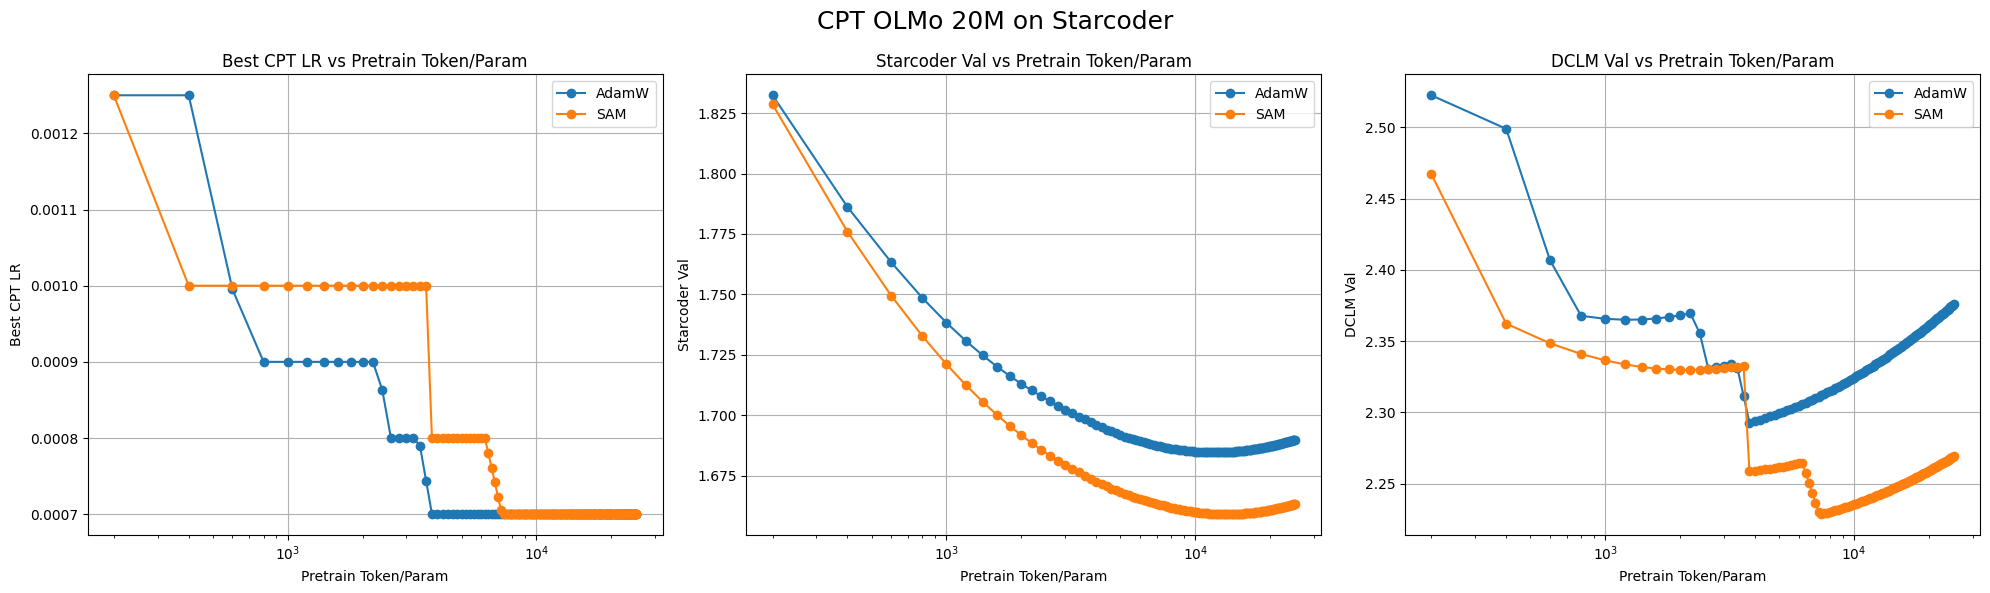

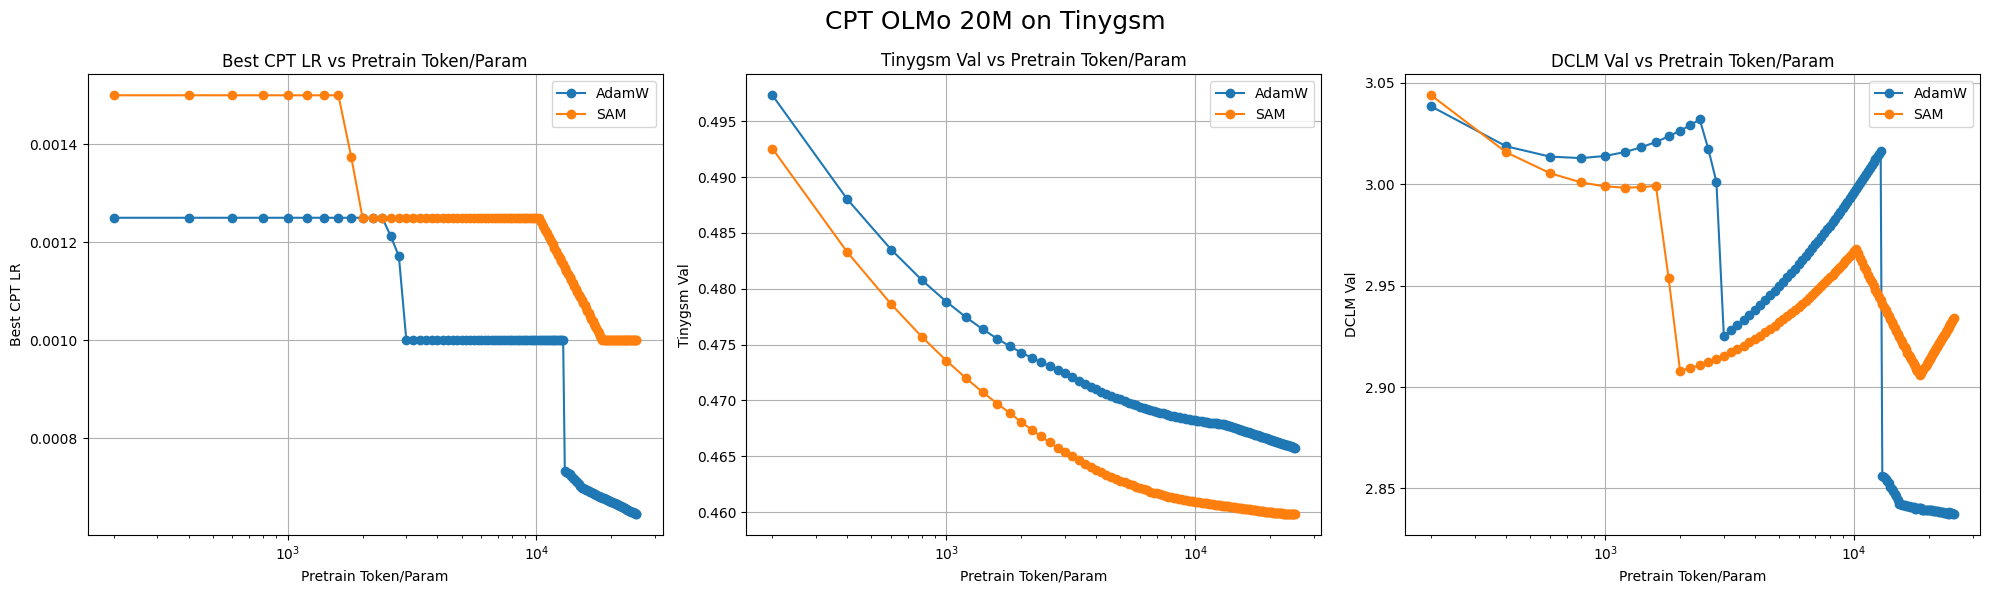

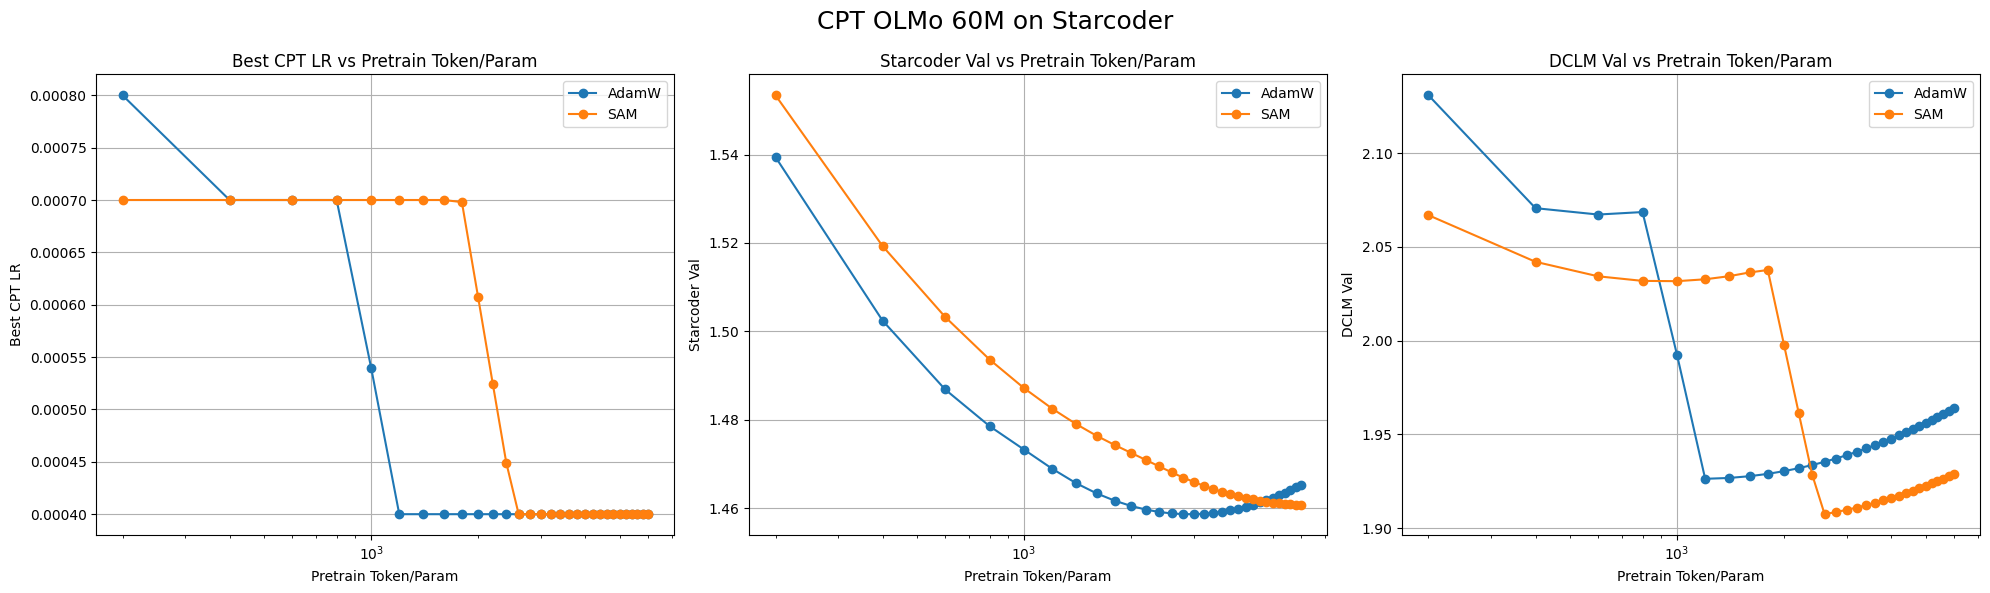

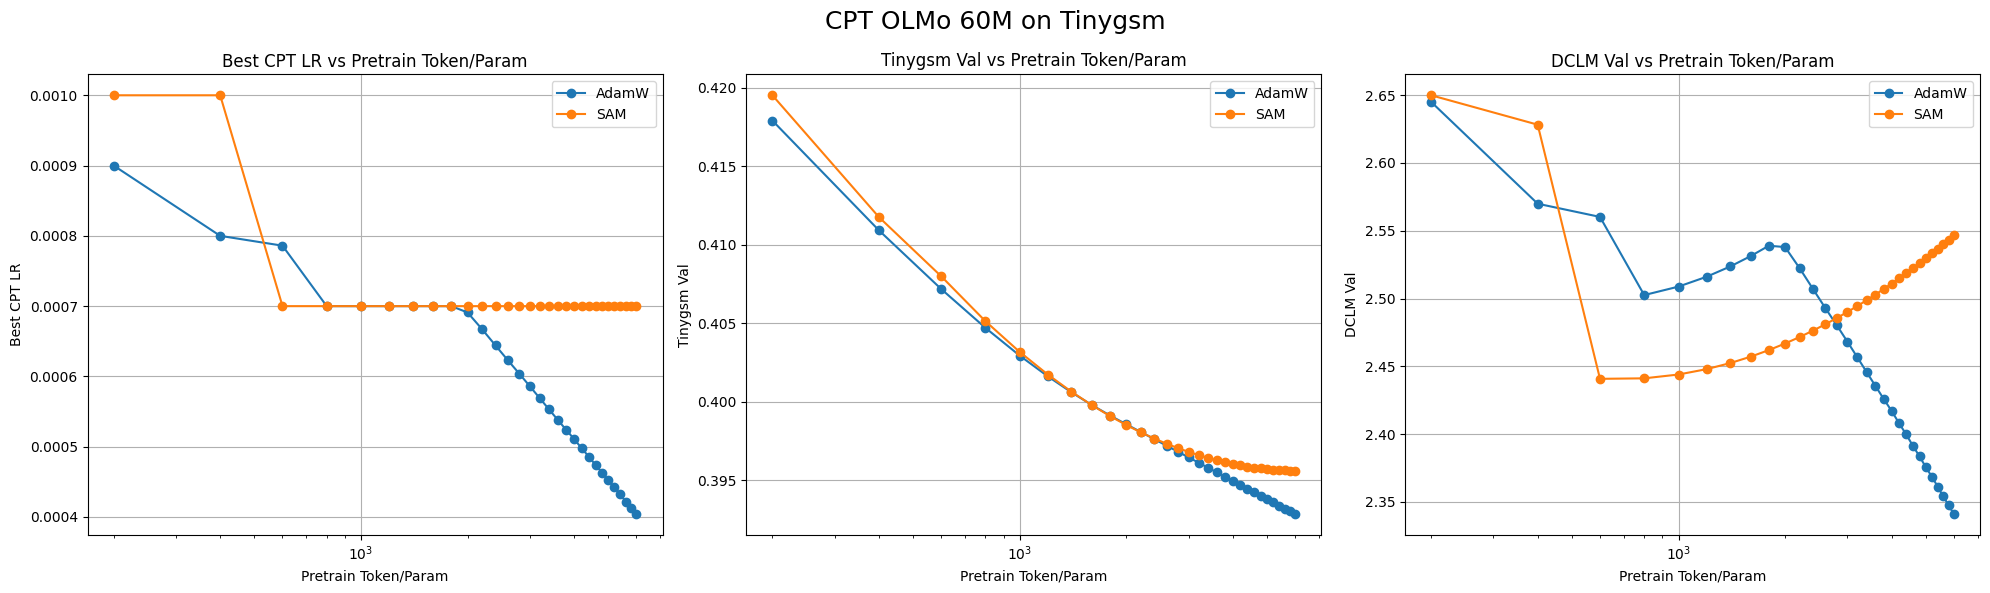

In [28]:
make_final_plots(interp=True, use_best_adamw=False, epsilon=1)

### Best CPT Plots

Missing Run: Optim AdamW | Token 32B | Size 20M
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset starcoder | CPT LR 0.004
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset starcoder | CPT LR 0.005
Missing Run: Optim SAM | Token 32B | Size 20M | CPT dataset starcoder | CPT LR 0.004
Missing Run: Optim SAM | Token 64B | Size 20M | CPT dataset starcoder | CPT LR 0.004
Missing Run: Optim SAM | Token 32B | Size 20M | CPT dataset starcoder | CPT LR 0.005
Missing Run: Optim SAM | Token 64B | Size 20M | CPT dataset starcoder | CPT LR 0.005


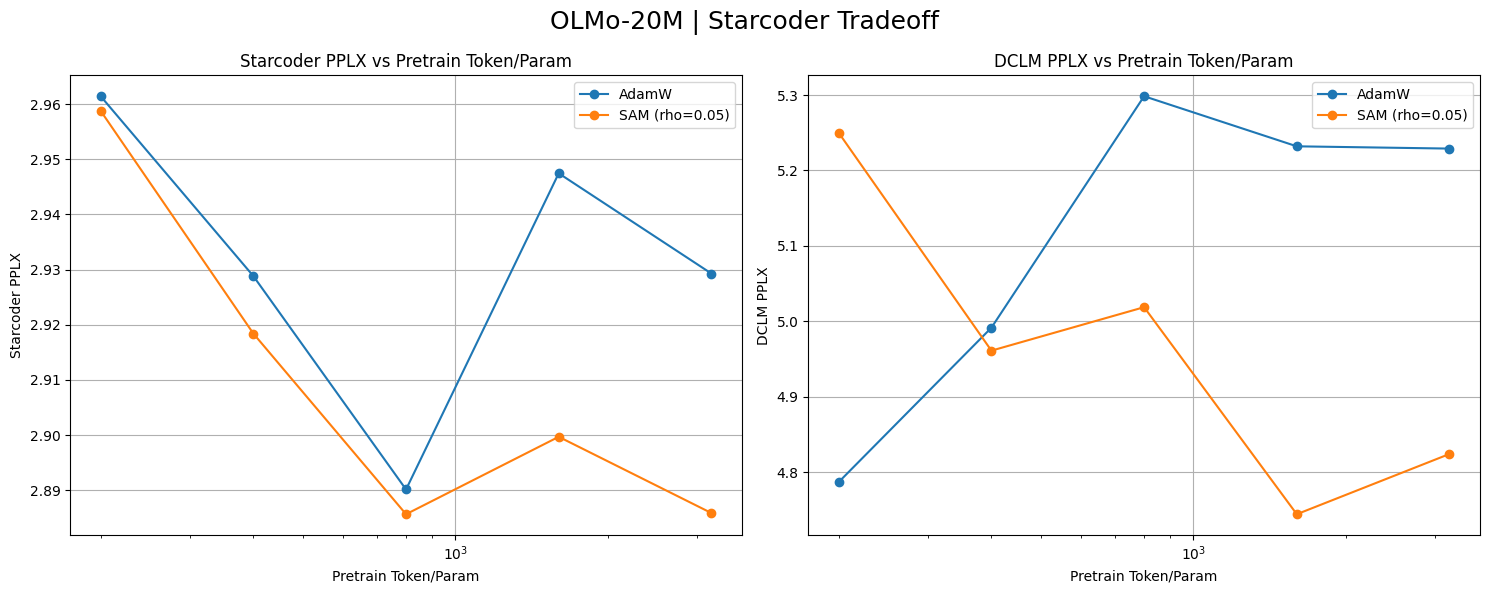

Missing Run: Optim AdamW | Token 32B | Size 20M
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset musicpile | CPT LR 0.004
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset musicpile | CPT LR 0.005
Missing Run: Optim SAM | Token 32B | Size 20M | CPT dataset musicpile | CPT LR 0.004
Missing Run: Optim SAM | Token 64B | Size 20M | CPT dataset musicpile | CPT LR 0.004
Missing Run: Optim SAM | Token 32B | Size 20M | CPT dataset musicpile | CPT LR 0.005
Missing Run: Optim SAM | Token 64B | Size 20M | CPT dataset musicpile | CPT LR 0.005


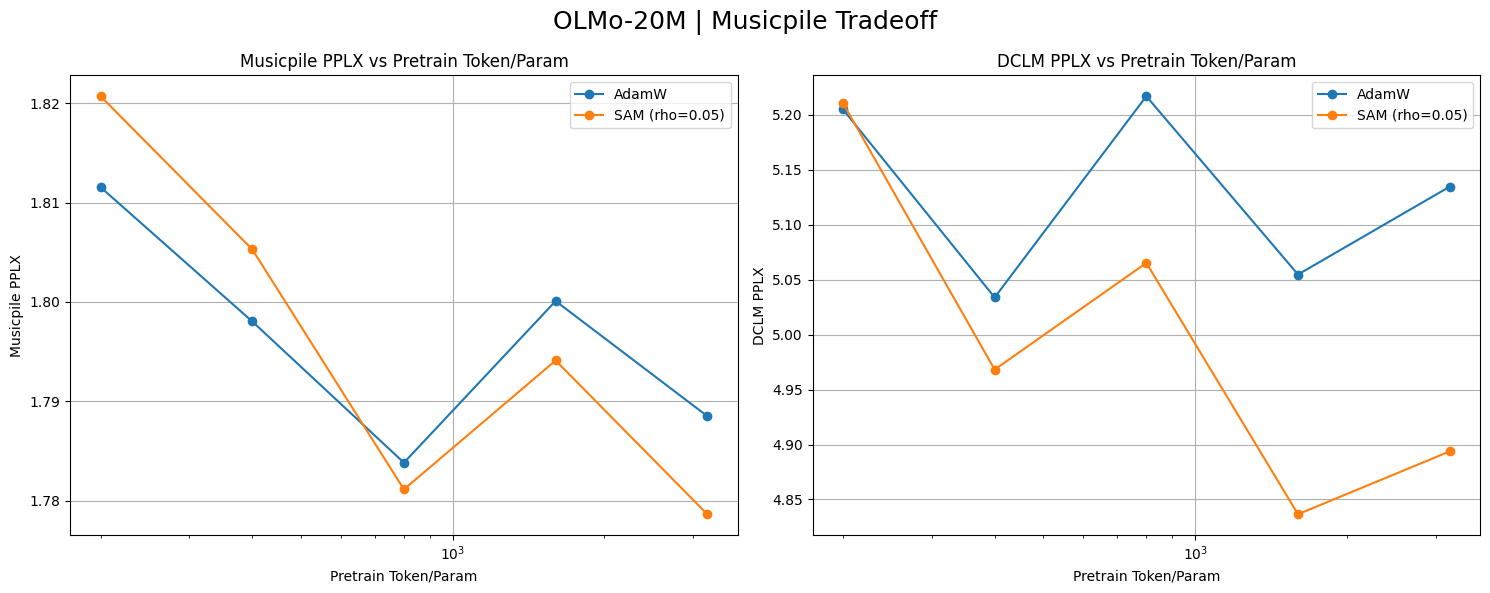

Missing Run: Optim AdamW | Token 32B | Size 20M
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset tulu | CPT LR 1e-05
Missing Run: Optim AdamW | Token 4B | Size 20M | CPT dataset tulu | CPT LR 0.0003
Missing Run: Optim AdamW | Token 8B | Size 20M | CPT dataset tulu | CPT LR 0.0003
Missing Run: Optim AdamW | Token 16B | Size 20M | CPT dataset tulu | CPT LR 0.0003
Missing Run: Optim AdamW | Token 32B | Size 20M | CPT dataset tulu | CPT LR 0.0003
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset tulu | CPT LR 0.0004
Missing Run: Optim AdamW | Token 32B | Size 20M | CPT dataset tulu | CPT LR 0.001
Missing Run: Optim AdamW | Token 64B | Size 20M | CPT dataset tulu | CPT LR 0.001
Missing Run: Optim SAM | Token 16B | Size 20M | CPT dataset tulu | CPT LR 1e-05
Missing Run: Optim SAM | Token 32B | Size 20M | CPT dataset tulu | CPT LR 1e-05
Missing Run: Optim SAM | Token 64B | Size 20M | CPT dataset tulu | CPT LR 1e-05
Missing Run: Optim SAM | Token 4B | Size 20M | CPT da

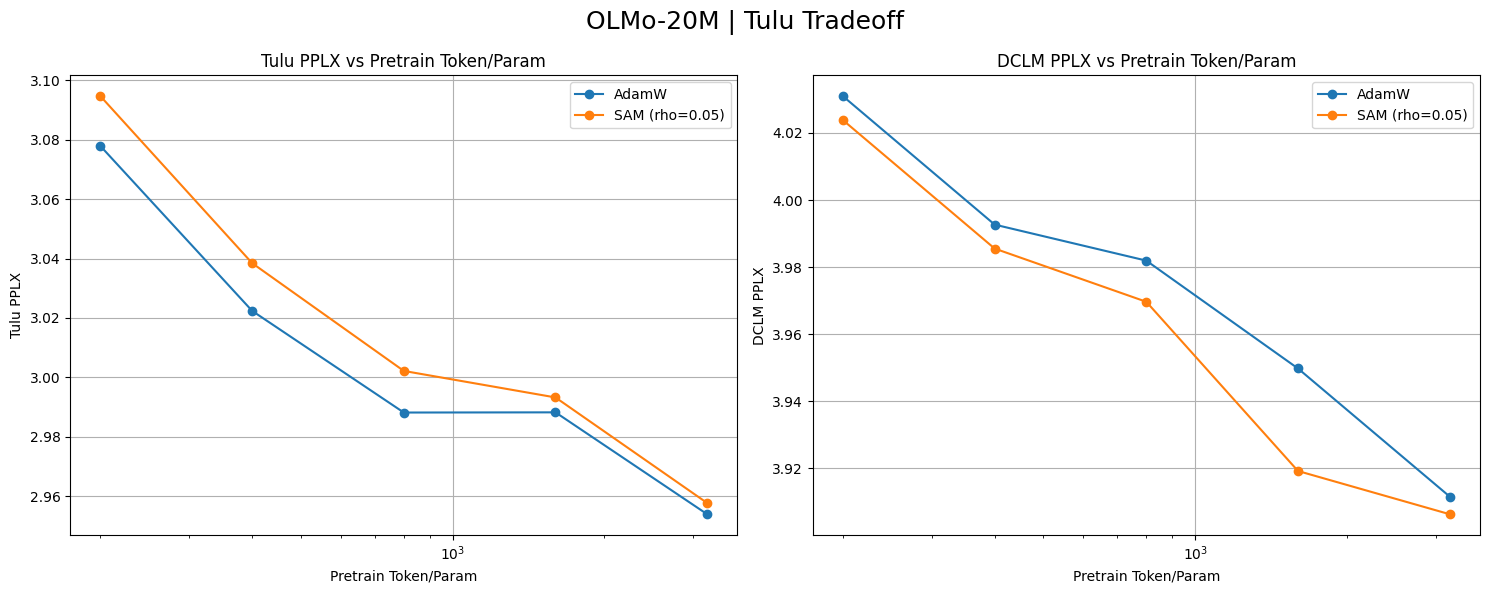

Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset starcoder | CPT LR 0.0003
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset starcoder | CPT LR 0.0003
Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset starcoder | CPT LR 0.0005
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset starcoder | CPT LR 0.0005
Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset starcoder | CPT LR 0.0006
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset starcoder | CPT LR 0.0006
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset starcoder | CPT LR 0.001
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset starcoder | CPT LR 0.00125
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset starcoder | CPT LR 0.0015
Missing Run: Optim AdamW | Token 48B | Size 60M | CPT dataset starcoder | CPT LR 0.00175
Missing Run: Optim AdamW | Token 96B | Size 60M | CPT dataset starcoder | CPT LR 0.00175
Missing Run: Optim AdamW | 

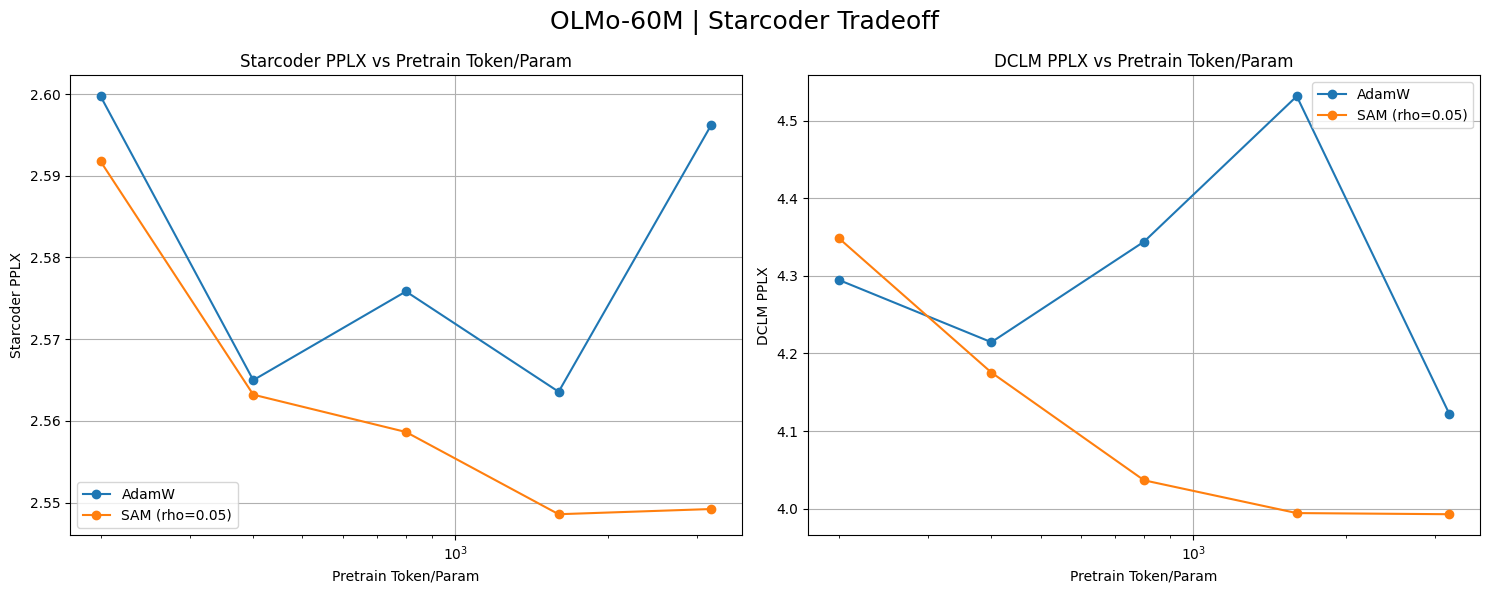

Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset musicpile | CPT LR 0.0002
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset musicpile | CPT LR 0.0002
Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset musicpile | CPT LR 0.0003
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset musicpile | CPT LR 0.0003
Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset musicpile | CPT LR 0.0005
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset musicpile | CPT LR 0.0005
Missing Run: Optim AdamW | Token 12B | Size 60M | CPT dataset musicpile | CPT LR 0.0006
Missing Run: Optim AdamW | Token 24B | Size 60M | CPT dataset musicpile | CPT LR 0.0006
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset musicpile | CPT LR 0.001
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset musicpile | CPT LR 0.0011
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset musicpile | CPT LR 0.00125
Missing Run: Optim AdamW | To

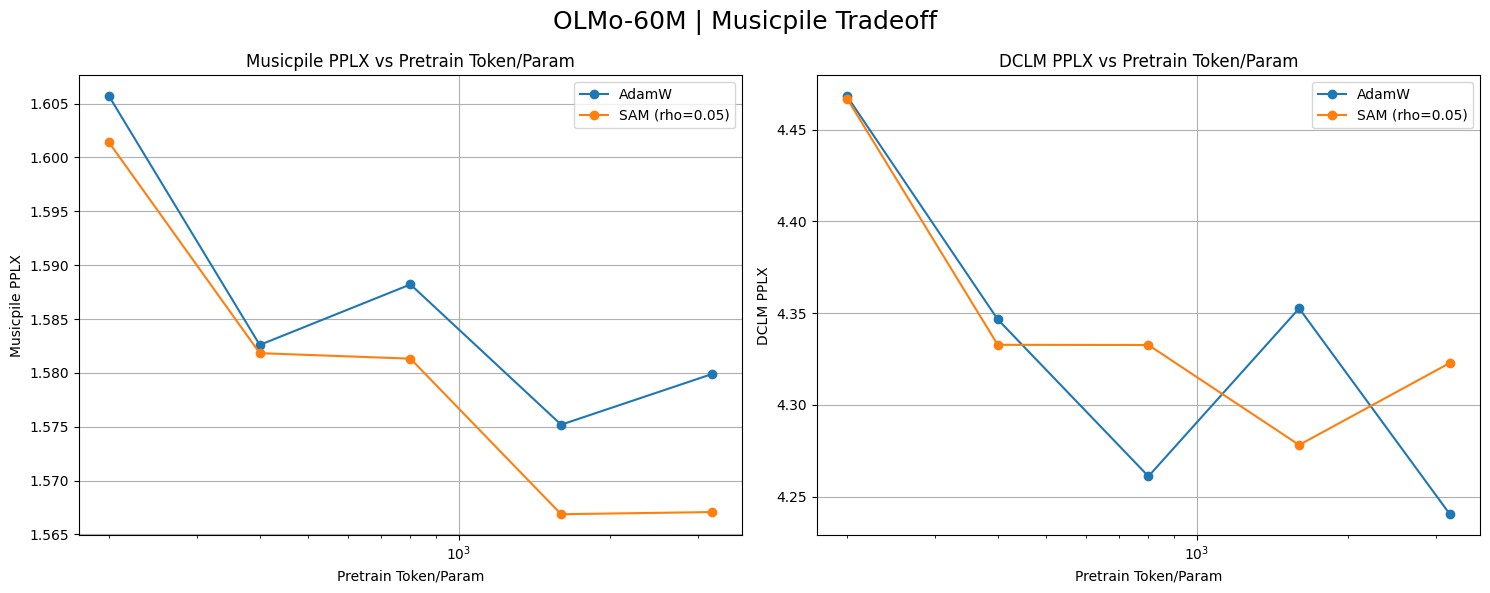

Missing Run: Optim AdamW | Token 48B | Size 60M | CPT dataset tulu | CPT LR 0.000125
Missing Run: Optim AdamW | Token 96B | Size 60M | CPT dataset tulu | CPT LR 0.000125
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset tulu | CPT LR 0.000125
Missing Run: Optim AdamW | Token 48B | Size 60M | CPT dataset tulu | CPT LR 0.00015
Missing Run: Optim AdamW | Token 96B | Size 60M | CPT dataset tulu | CPT LR 0.00015
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset tulu | CPT LR 0.00015
Missing Run: Optim AdamW | Token 48B | Size 60M | CPT dataset tulu | CPT LR 0.000175
Missing Run: Optim AdamW | Token 96B | Size 60M | CPT dataset tulu | CPT LR 0.000175
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset tulu | CPT LR 0.000175
Missing Run: Optim AdamW | Token 48B | Size 60M | CPT dataset tulu | CPT LR 0.0004
Missing Run: Optim AdamW | Token 96B | Size 60M | CPT dataset tulu | CPT LR 0.0004
Missing Run: Optim AdamW | Token 192B | Size 60M | CPT dataset tulu |

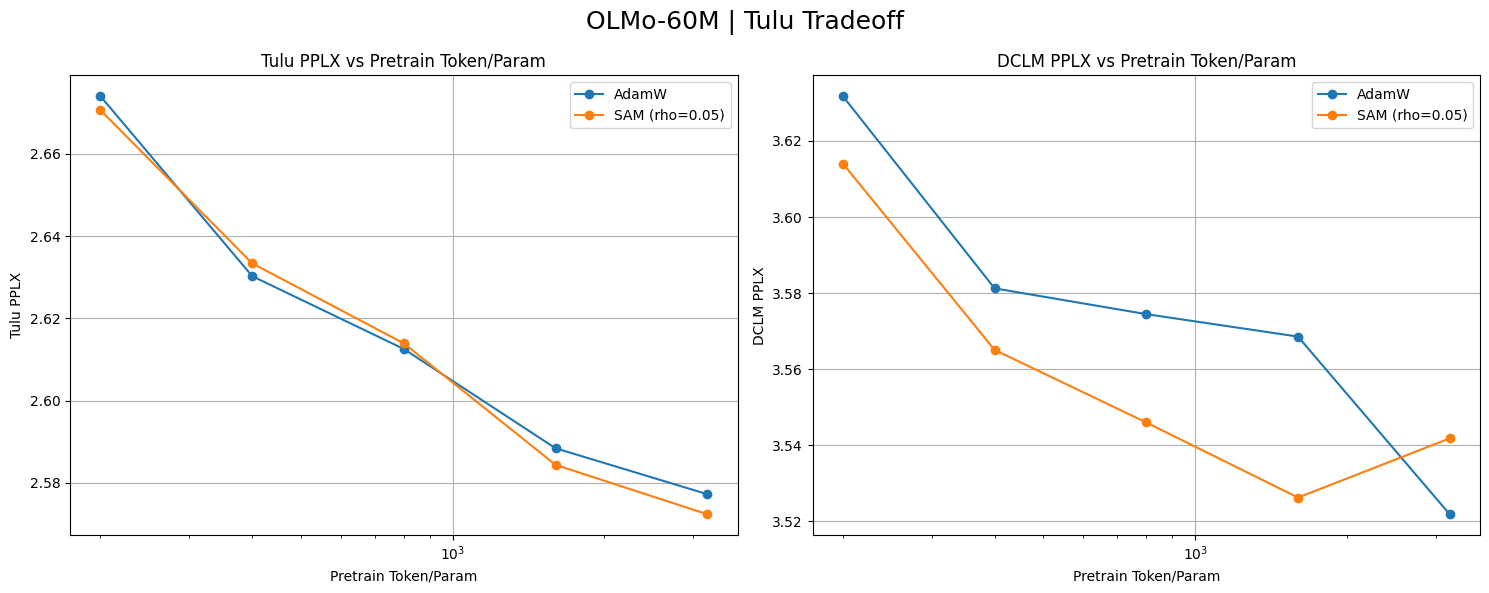

In [54]:
for size in SIZE:
    for cpt_dataset in CPT_DATASET:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        tokens_list = sorted(np.unique(list(CHECKPOINT_MAP[size].values())))

        for optim in OPTIM:
            if optim == "adamw":
                run_info = get_run_info(size, optim, cpt_dataset)
                best_results = {
                    "x" : [],
                    "cpt": [],
                    "pt": []
                }
                for t in tokens_list:
                    cpt_lrs = sorted(list(run_info["cpt"].keys()))
                    best_cpt_val = float('inf')
                    best_pt_val = float('inf')
                    for cpt_lr in cpt_lrs:
                        try:
                            cpt_val = run_info["cpt"][cpt_lr][t][cpt_dataset]
                            dclm_val = run_info["cpt"][cpt_lr][t]["dclm"]
                            x = run_info["cpt"][cpt_lr][t]["multiplier"]

                            if cpt_val <= best_cpt_val:
                                best_cpt_val = cpt_val
                                best_pt_val = dclm_val
                        except:
                            continue
                    
                    best_results["x"].append(x)
                    best_results["cpt"].append(best_cpt_val)
                    best_results["pt"].append(best_pt_val)

                ax1.plot(best_results["x"], best_results["cpt"], marker="o", label=OPTIM_MAP[optim])
                ax2.plot(best_results["x"], best_results["pt"], marker="o", label=OPTIM_MAP[optim])
                    
            elif optim == "sam":
                for rho in RHO:
                    run_info = get_run_info(size, optim, cpt_dataset, rho=rho)
                    
                    best_results = {
                        "x" : [],
                        "cpt": [],
                        "pt": []
                    }
                    for t in tokens_list:
                        cpt_lrs = sorted(list(run_info["cpt"].keys()))
                        best_cpt_val = float('inf')
                        best_pt_val = float('inf')
                        for cpt_lr in cpt_lrs:
                            try:
                                cpt_val = run_info["cpt"][cpt_lr][t][cpt_dataset]
                                dclm_val = run_info["cpt"][cpt_lr][t]["dclm"]
                                x = run_info["cpt"][cpt_lr][t]["multiplier"]

                                if cpt_val <= best_cpt_val:
                                    best_cpt_val = cpt_val
                                    best_pt_val = dclm_val
                            except:
                                continue
                        
                        best_results["x"].append(x)
                        best_results["cpt"].append(best_cpt_val)
                        best_results["pt"].append(best_pt_val)

                    ax1.plot(best_results["x"], best_results["cpt"], marker="o", label=f"{OPTIM_MAP[optim]} (rho={rho})")
                    ax2.plot(best_results["x"], best_results["pt"], marker="o", label=f"{OPTIM_MAP[optim]} (rho={rho})")

        ax1.set_title(f"{cpt_dataset.capitalize()} PPLX vs Pretrain Token/Param")
        ax1.set_xlabel("Pretrain Token/Param")
        ax1.set_ylabel(f"{cpt_dataset.capitalize()} PPLX")
        ax1.set_xscale('log')
        ax1.grid(True)
        ax1.legend()

        ax2.set_title("DCLM PPLX vs Pretrain Token/Param")
        ax2.set_xlabel("Pretrain Token/Param")
        ax2.set_ylabel("DCLM PPLX")
        ax2.set_xscale('log')
        ax2.grid(True)
        ax2.legend()

        plt.suptitle(f"OLMo-{size}M | {cpt_dataset.capitalize()} Tradeoff", fontsize=18)
        plt.tight_layout()
        if SAVE:
            os.makedirs(os.path.join(results_dir, f"plots/tradeoff/{size}/{cpt_dataset}"), exist_ok=True)
            plt.savefig(os.path.join(results_dir, f"plots/tradeoff/{size}/{cpt_dataset}/tradeoff.png"), bbox_inches='tight')
            plt.close()
        else:
            plt.show()

            
        

## Tradeoff Plots

In [27]:
YLIM = {
    150: {
        "starcoder": (2, 2.5),
        "musicpile" : (1, 1.55),
        "tulu": (2, 3),
    },
    60: {
        "starcoder": (2.5, 2.8),
        "musicpile" : (1.5, 1.7),
        "tulu": (2.5, 3),
    },
    20: {
        "starcoder": (2.5, 3.5),
        "musicpile" : (1.5, 2.25),
        "tulu": (2.5, 3.5),
    }
}
XLIM = {
    150: {
        "starcoder": (1, 6),
        "musicpile" : (1, 5),
        "tulu": (2, 3.5),
    },
    60: {
        "starcoder": (3.5, 5.2),
        "musicpile" : (3.5, 5),
        "tulu": (3.4, 3.8),
    },
    20: {
        "starcoder": (3.5, 6.5),
        "musicpile" : (3.5, 6.5),
        "tulu": (3.8, 4.2),
    }
}

In [ ]:
YLIM = {
    60: {
        "starcoder": (1,9),
        "musicpile" : (0,5),
        "tulu": (1,5),
    },
}
XLIM = {
    60: {
        "starcoder": (1,7),
        "musicpile" : (1,7),
        "tulu": (1,3.75),
    },
}

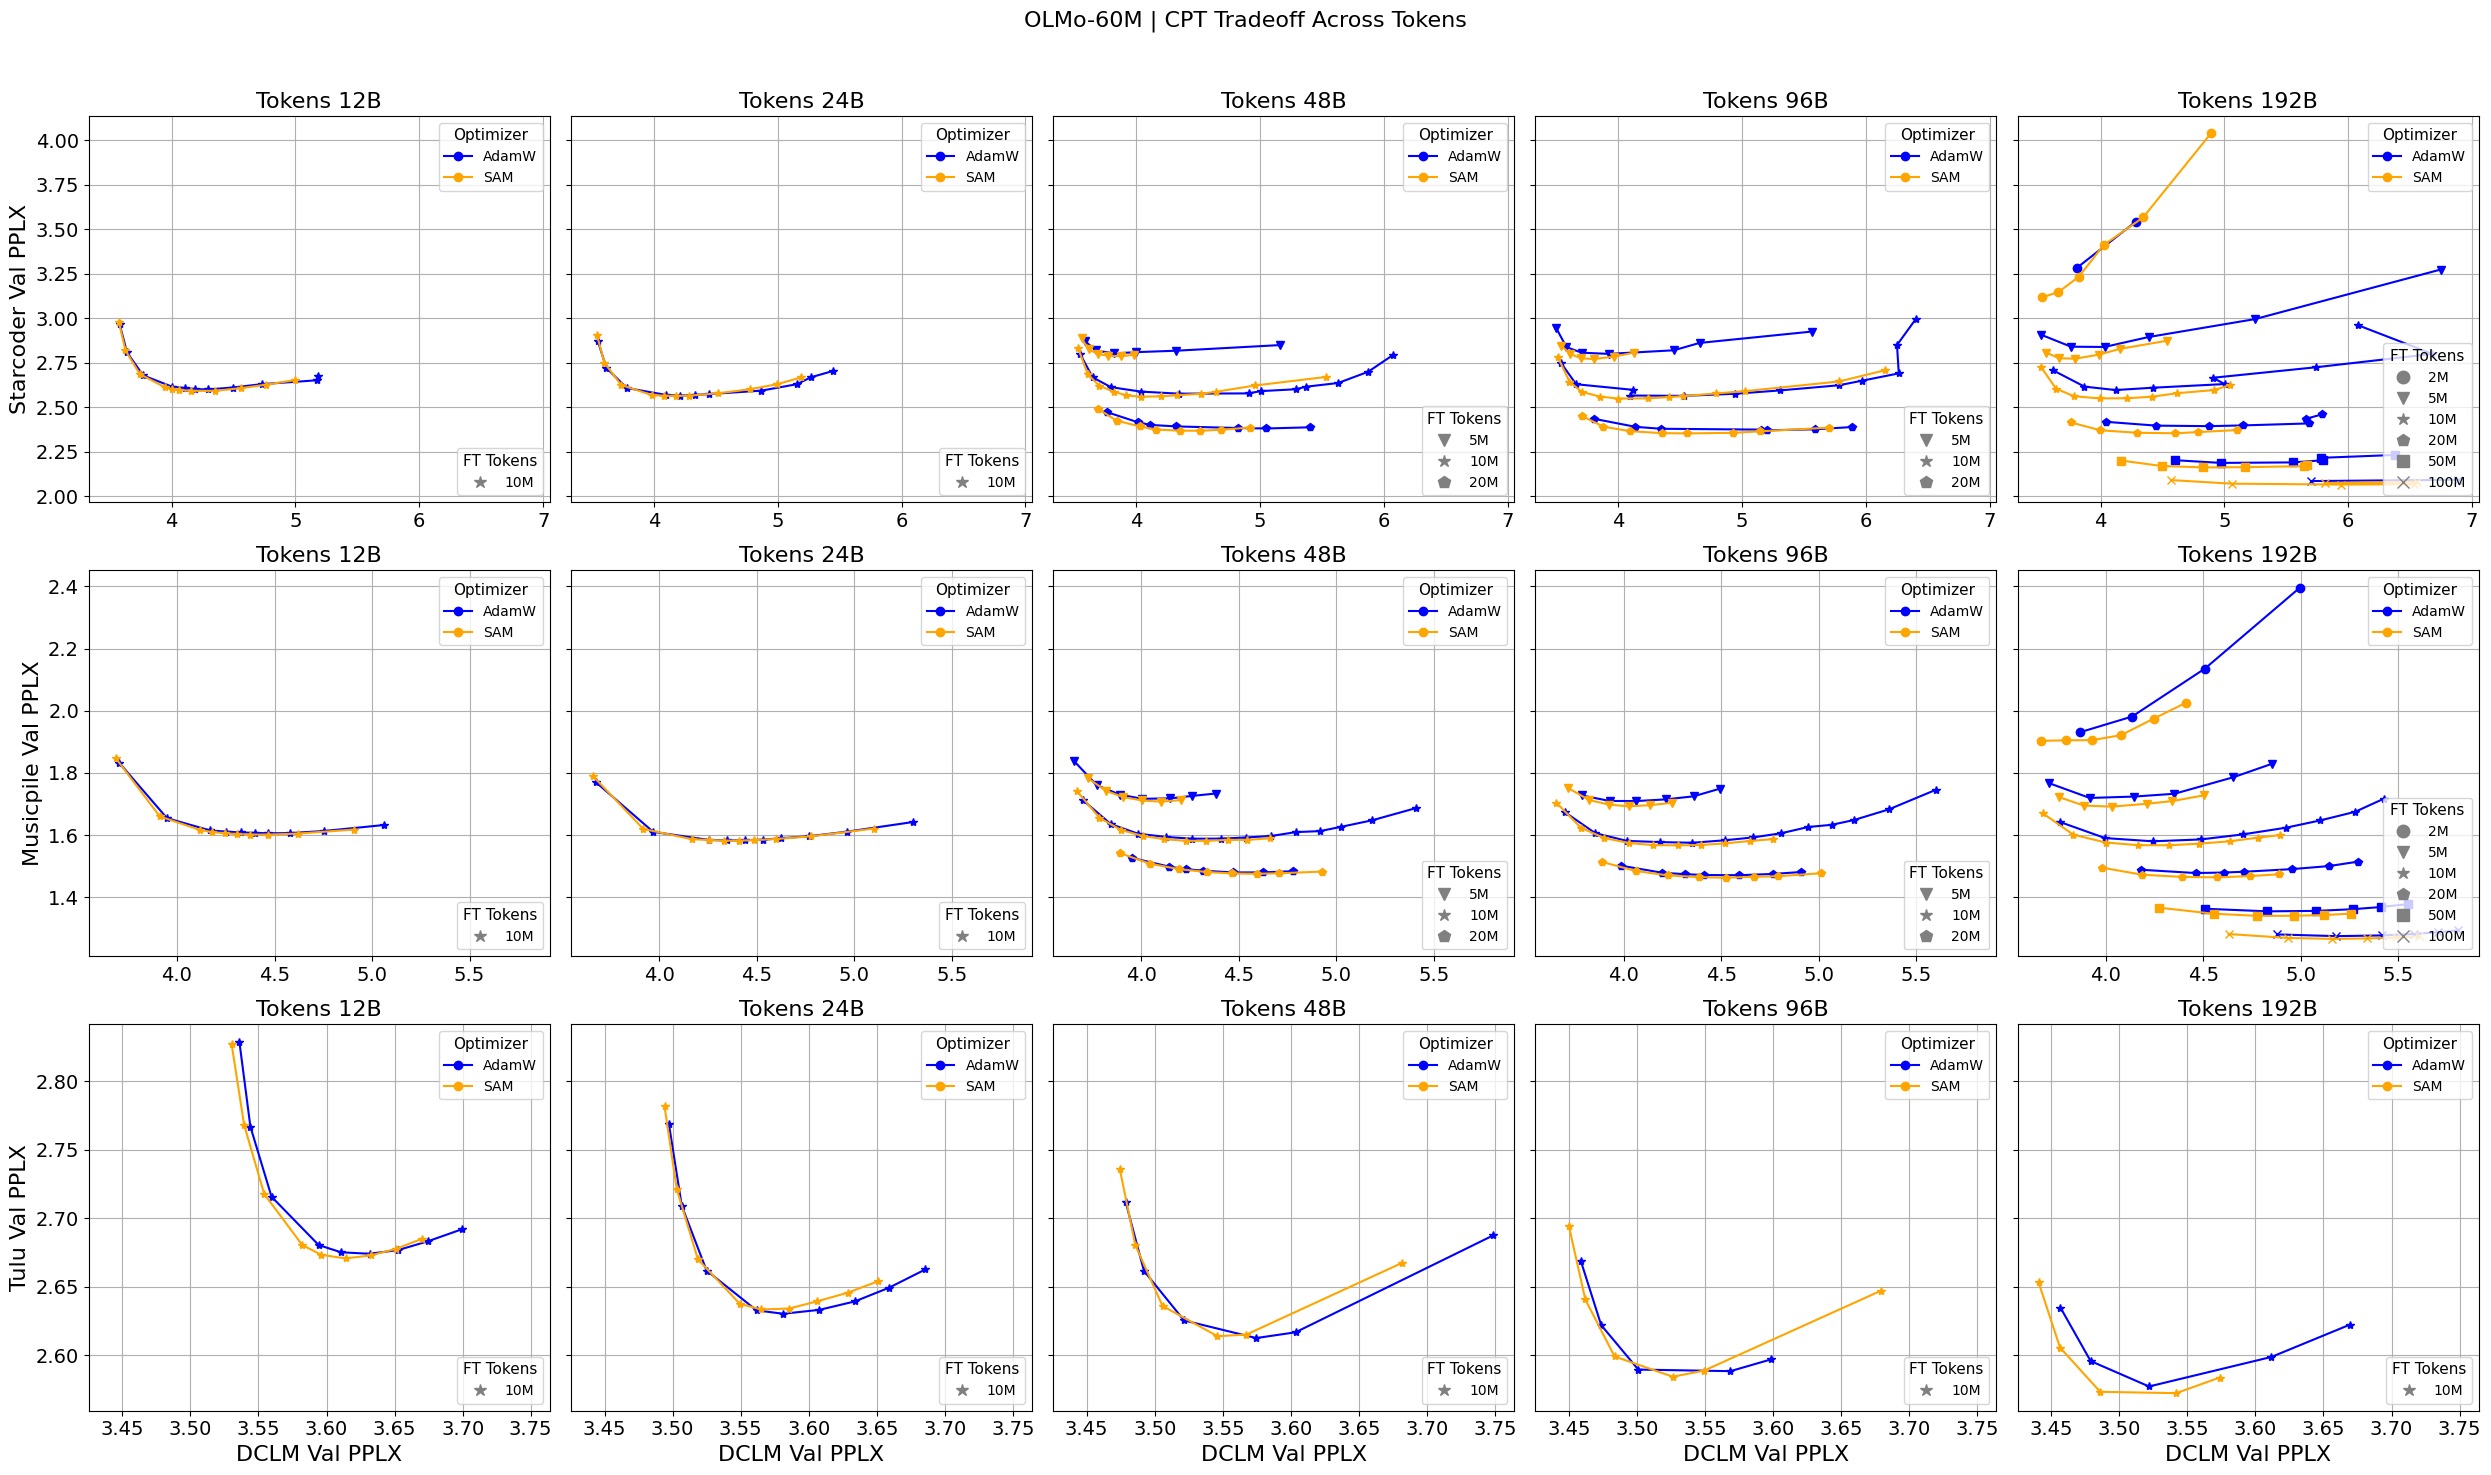

In [ ]:
import matplotlib.lines as mlines

markers = ["o", "v", "*", "p", "s", "x"]  # marker for cpt_tokens
optim_colors = {"adamw": "blue", "sam": "orange"}

for size in [60]:
    tokens_list = sorted(np.unique(list(CHECKPOINT_MAP[size].values())))
    fig, axs = plt.subplots(len(CPT_DATASET), len(tokens_list), figsize=(5 * len(tokens_list), 5 * len(CPT_DATASET)), sharey="row", sharex="row")
    # Ensure axs is 2d array even if len(CPT_DATASET)==1 or len(tokens_list)==1
    if len(CPT_DATASET) == 1:
        axs = np.expand_dims(axs, axis=0)
    if len(tokens_list) == 1:
        axs = np.expand_dims(axs, axis=1)
    for row, cpt_dataset in enumerate(CPT_DATASET):
        for col, t in enumerate(tokens_list):
            ax = axs[row][col]
            handles_method = []
            handles_token = []
            already_legend_optim = {}
            already_legend_token = {}

            for i_cpt_token, cpt_token in enumerate([2, 5, 10, 20, 50, 100]):
                for optim in OPTIM:
                    if optim == "adamw":
                        for l, pt_lr in enumerate(["adapt"]):
                            run_info = get_run_info(size, optim, cpt_dataset, pt_lr=pt_lr, cpt_tokens=cpt_token)
                            if run_info is None:
                                continue

                            cpt_lrs = sorted(run_info["cpt"].keys())
                            dclm_val = []
                            cpt_val = []
                            used_cpt_lrs = []
                            for cpt_lr in cpt_lrs:
                                try:
                                    x_val = run_info["cpt"][cpt_lr][t]["dclm_val"]
                                    y_val = run_info["cpt"][cpt_lr][t][cpt_dataset]
                                    if x_val >= XLIM[size][cpt_dataset][0] and x_val <= XLIM[size][cpt_dataset][1] and y_val >= YLIM[size][cpt_dataset][0] and y_val <= YLIM[size][cpt_dataset][1]:
                                        dclm_val.append(x_val)
                                        cpt_val.append(y_val)
                                        used_cpt_lrs.append(cpt_lr)
                                except:
                                    continue

                            if len(dclm_val) > 0:
                                ax.plot(
                                    dclm_val, cpt_val,
                                    marker=markers[i_cpt_token],
                                    color=optim_colors[optim],
                                    label=None
                                )

                                # For token legend (only needs one example per token)
                                if cpt_token not in already_legend_token:
                                    h = mlines.Line2D([], [], color="gray", marker=markers[i_cpt_token], linestyle='None', markersize=9, label=f'{cpt_token}M')
                                    handles_token.append(h)
                                    already_legend_token[cpt_token] = True

                                # For optim legend (only needs one example per optim)
                                if optim not in already_legend_optim:
                                    h_opt = mlines.Line2D([], [], color=optim_colors[optim], marker='o', linestyle='-', label=OPTIM_MAP[optim])
                                    handles_method.append(h_opt)
                                    already_legend_optim[optim] = True

                            # for x, y, lr in zip(dclm_val, cpt_val, used_cpt_lrs):
                            #     ax.text(x, y, f"{lr}", fontsize=8, ha='right', va='bottom', color='black')

                    if optim == "sam":
                        for l, pt_lr in enumerate(["adapt"]):
                            for rho in RHO:
                                run_info = get_run_info(size, optim, cpt_dataset, pt_lr=pt_lr, rho=rho, cpt_tokens=cpt_token)
                                if run_info is None:
                                    continue

                                cpt_lrs = sorted(run_info["cpt"].keys())
                                dclm_val = []
                                cpt_val = []
                                used_cpt_lrs = []
                                for cpt_lr in cpt_lrs:
                                    try:
                                        x_val = run_info["cpt"][cpt_lr][t]["dclm_val"]
                                        y_val = run_info["cpt"][cpt_lr][t][cpt_dataset]

                                        if x_val >= XLIM[size][cpt_dataset][0] and x_val <= XLIM[size][cpt_dataset][1] and y_val >= YLIM[size][cpt_dataset][0] and y_val <= YLIM[size][cpt_dataset][1]:
                                            dclm_val.append(x_val)
                                            cpt_val.append(y_val)
                                            used_cpt_lrs.append(cpt_lr)
                                    except:
                                        continue

                                if len(dclm_val) > 0:
                                    ax.plot(
                                        dclm_val, cpt_val,
                                        marker=markers[i_cpt_token],
                                        color=optim_colors[optim],
                                        label=None
                                    )

                                    # For token legend (only needs one example per token)
                                    if cpt_token not in already_legend_token:
                                        h = mlines.Line2D([], [], color="gray", marker=markers[i_cpt_token], linestyle='None', markersize=9, label=f'{cpt_token}M')
                                        handles_token.append(h)
                                        already_legend_token[cpt_token] = True

                                    # For optim legend (only needs one example per optim)
                                    if optim not in already_legend_optim:
                                        h_opt = mlines.Line2D([], [], color=optim_colors[optim], marker='o', linestyle='-', label=OPTIM_MAP[optim])
                                        handles_method.append(h_opt)
                                        already_legend_optim[optim] = True

                                # Optionally add text labels here if desired

            if row == len(CPT_DATASET)-1:
                ax.set_xlabel("DCLM Val PPLX", fontsize=AXIS_FONTSIZE)
            if col == 0:
                ax.set_ylabel(f"{cpt_dataset.capitalize()} Val PPLX", fontsize=AXIS_FONTSIZE)
            ax.set_title(f"Tokens {t}B", fontsize=TITLE_FONTSIZE)
            # Place two legends: one for optim, one for cpt_token
            leg1 = ax.legend(handles=handles_method, title="Optimizer", loc='upper right', fontsize=10, title_fontsize=11, frameon=True)
            ax.add_artist(leg1)
            ax.legend(handles=handles_token, title="FT Tokens", loc='lower right', fontsize=10, title_fontsize=11, frameon=True)
            # Set tick params for tick fontsize
            ax.tick_params(axis='both', which='major', labelsize=TICKS_FONTSIZE)
            ax.tick_params(axis='both', which='minor', labelsize=TICKS_FONTSIZE)
            ax.grid(True)
    fig.suptitle(f"OLMo-{size}M | CPT Tradeoff Across Tokens", fontsize=TITLE_FONTSIZE)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if SAVE:
        os.makedirs(os.path.join(results_dir, f"plots/tradeoff/"), exist_ok=True)
        plt.savefig(os.path.join(results_dir, f"plots/tradeoff/{size}_tradeoff_all_tokens.png"), bbox_inches='tight')
        plt.close()
    else:
        plt.show()


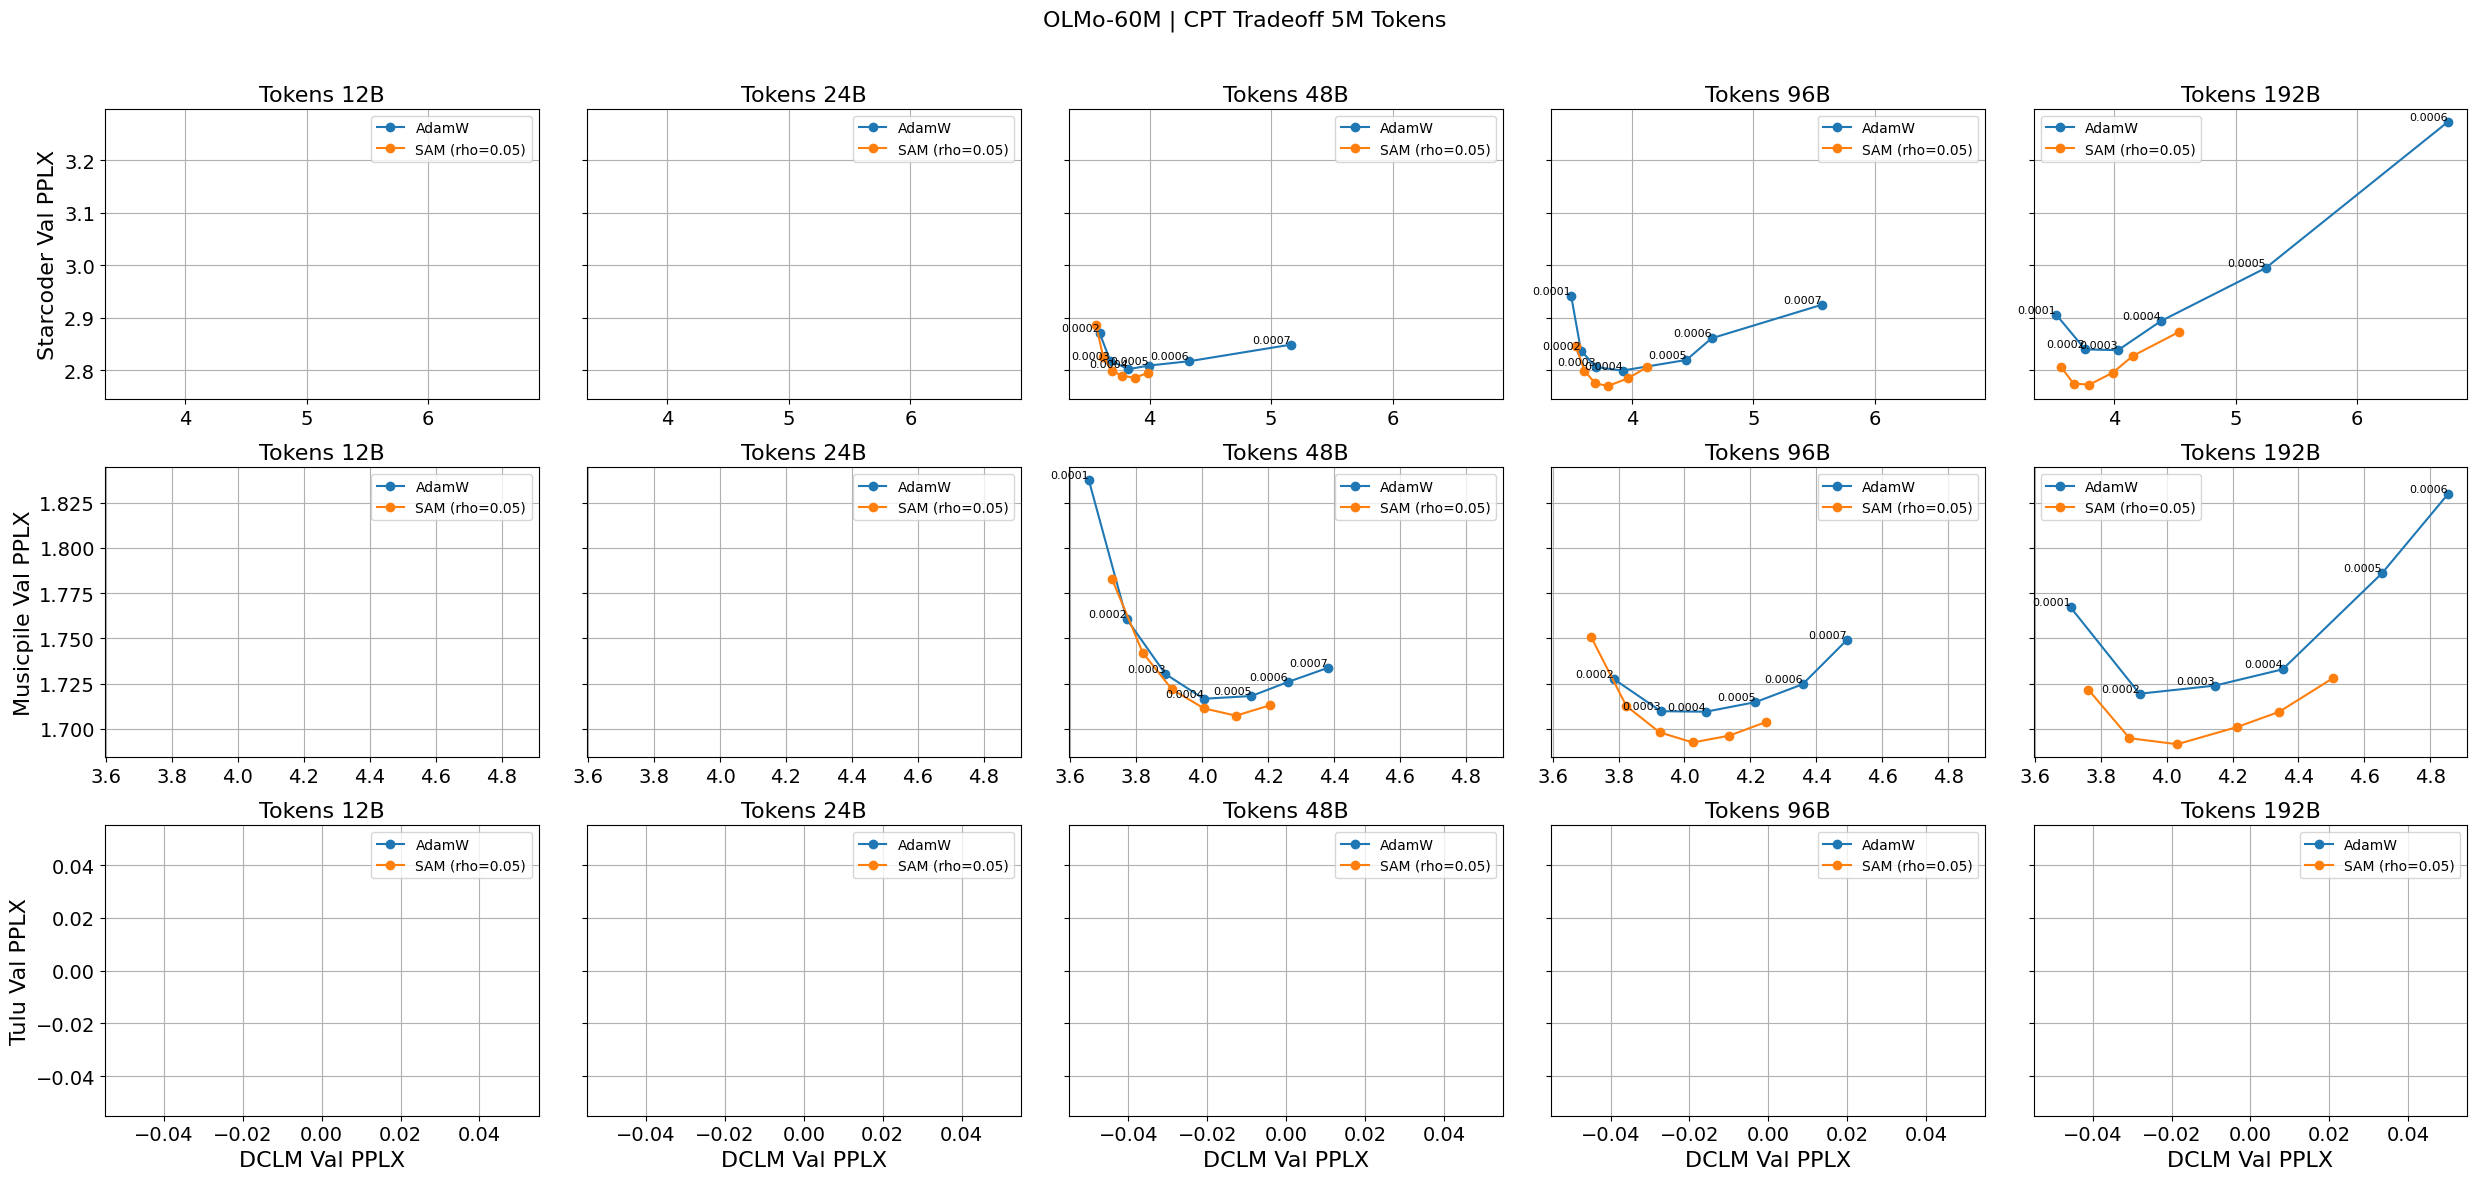

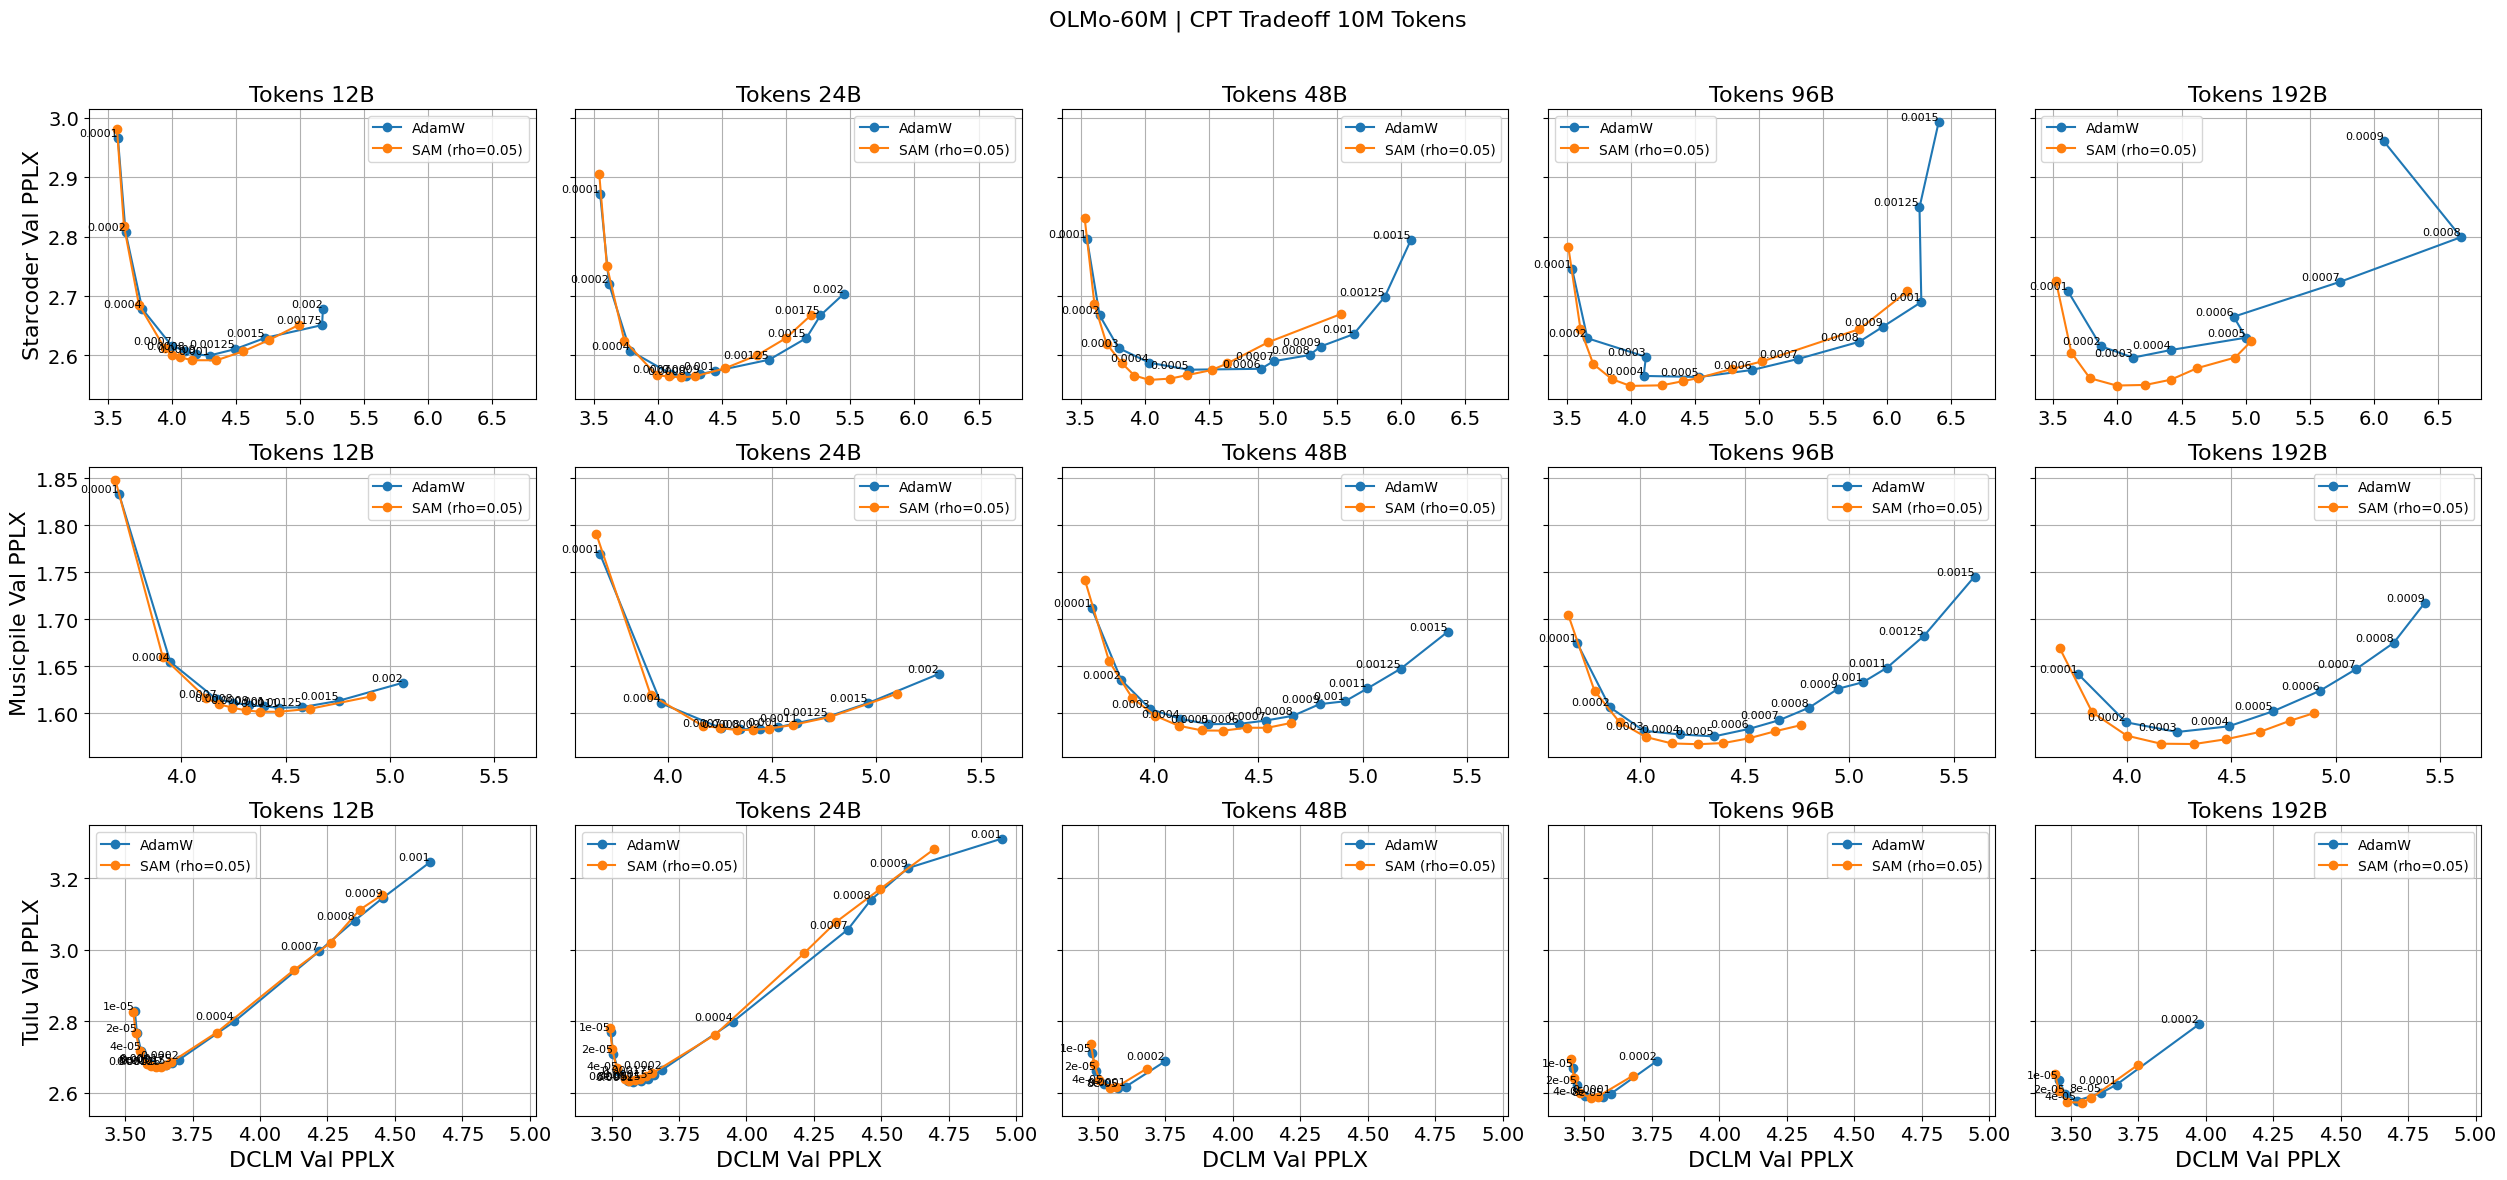

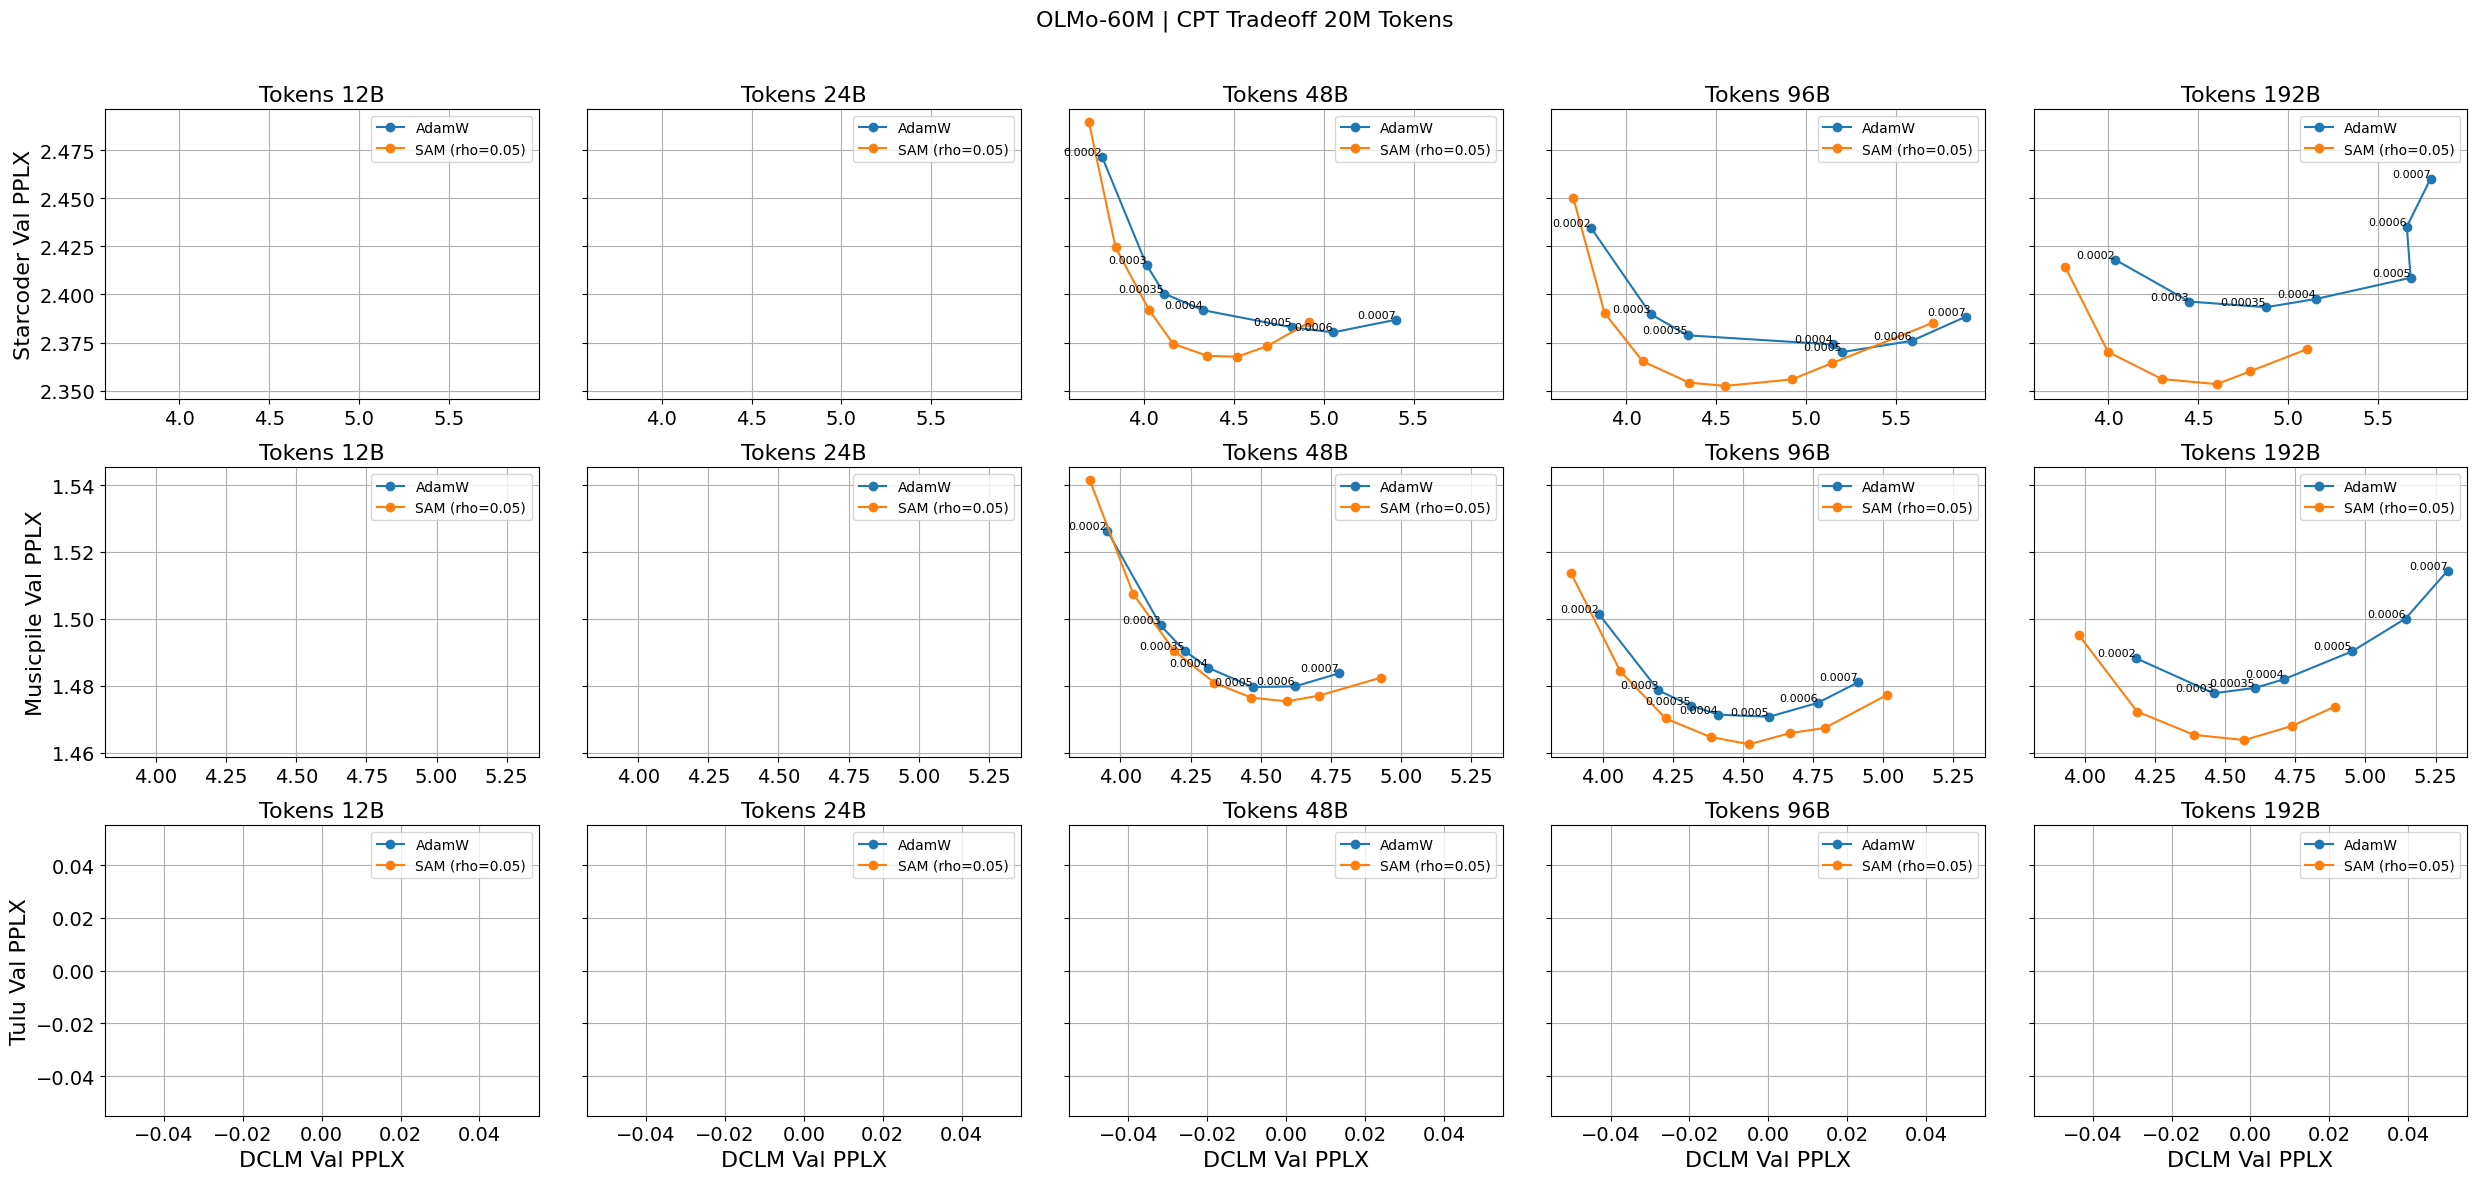

In [ ]:
markers = ["o", "v"]

for cpt_token in [2, 5, 10, 20, 50, 100]:
    for size in [60]:
        tokens_list = sorted(np.unique(list(CHECKPOINT_MAP[size].values())))
        fig, axs = plt.subplots(len(CPT_DATASET), len(tokens_list), figsize=(5 * len(tokens_list), 4 * len(CPT_DATASET)), sharey="row", sharex="row")
        # Ensure axs is 2d array even if len(CPT_DATASET)==1 or len(tokens_list)==1
        if len(CPT_DATASET) == 1:
            axs = np.expand_dims(axs, axis=0)
        if len(tokens_list) == 1:
            axs = np.expand_dims(axs, axis=1)
        for row, cpt_dataset in enumerate(CPT_DATASET):
            
            for col, t in enumerate(tokens_list):
                ax = axs[row][col]
                for optim in OPTIM:
                    if optim == "adamw":
                        for l, pt_lr in enumerate(["adapt"]):
                            run_info = get_run_info(size, optim, cpt_dataset, pt_lr=pt_lr, cpt_tokens=cpt_token)
                            if run_info is None:
                                continue

                            cpt_lrs = sorted(run_info["cpt"].keys())
                            dclm_val = []
                            cpt_val = []
                            used_cpt_lrs = []
                            for cpt_lr in cpt_lrs:
                                try:
                                    x_val = run_info["cpt"][cpt_lr][t]["dclm_val"]
                                    y_val = run_info["cpt"][cpt_lr][t][cpt_dataset]

                                    if x_val >= XLIM[size][cpt_dataset][0] and x_val <= XLIM[size][cpt_dataset][1] and y_val >= YLIM[size][cpt_dataset][0] and y_val <= YLIM[size][cpt_dataset][1]:
                                        dclm_val.append(x_val)
                                        cpt_val.append(y_val)
                                        used_cpt_lrs.append(cpt_lr)
                                except:
                                    continue

                            ax.plot(dclm_val, cpt_val, label = f"{OPTIM_MAP[optim]}" if pt_lr == "adapt" else f"{OPTIM_MAP[optim]} (pt_lr={pt_lr})", marker=markers[l])
                        for x, y, lr in zip(dclm_val, cpt_val, used_cpt_lrs):
                            ax.text(x, y, f"{lr}", fontsize=8, ha='right', va='bottom', color='black')

                    if optim == "sam":
                        for l, pt_lr in enumerate(["adapt"]):
                            for rho in RHO:
                                run_info = get_run_info(size, optim, cpt_dataset, pt_lr=pt_lr, rho=rho, cpt_tokens=cpt_token)
                                if run_info is None:
                                    continue

                                cpt_lrs = sorted(run_info["cpt"].keys())
                                dclm_val = []
                                cpt_val = []
                                used_cpt_lrs = []
                                for cpt_lr in cpt_lrs:
                                    try:
                                        x_val = run_info["cpt"][cpt_lr][t]["dclm_val"]
                                        y_val = run_info["cpt"][cpt_lr][t][cpt_dataset]

                                        if x_val >= XLIM[size][cpt_dataset][0] and x_val <= XLIM[size][cpt_dataset][1] and y_val >= YLIM[size][cpt_dataset][0] and y_val <= YLIM[size][cpt_dataset][1]:
                                            dclm_val.append(x_val)
                                            cpt_val.append(y_val)
                                            used_cpt_lrs.append(cpt_lr)
                                    except:
                                        continue

                                ax.plot(dclm_val, cpt_val, label = f"{OPTIM_MAP[optim]} (rho={rho})", marker=markers[l])
                            # Optionally add text labels here if desired

                if row == len(CPT_DATASET)-1:
                    ax.set_xlabel("DCLM Val PPLX", fontsize=AXIS_FONTSIZE)
                if col == 0:
                    ax.set_ylabel(f"{cpt_dataset.capitalize()} Val PPLX", fontsize=AXIS_FONTSIZE)
                ax.set_title(f"Tokens {t}B", fontsize=TITLE_FONTSIZE)
                ax.legend()
                # Set tick params for tick fontsize
                ax.tick_params(axis='both', which='major', labelsize=TICKS_FONTSIZE)
                ax.tick_params(axis='both', which='minor', labelsize=TICKS_FONTSIZE)
                # if size == 60:
                #     ax.set_ylim(YLIM[cpt_dataset])
                #     ax.set_xlim(XLIM[cpt_dataset])
                ax.grid(True)
        fig.suptitle(f"OLMo-{size}M | CPT Tradeoff {cpt_token}M Tokens", fontsize=TITLE_FONTSIZE)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        if SAVE:
            os.makedirs(os.path.join(results_dir, f"plots/tradeoff/"), exist_ok=True)
            plt.savefig(os.path.join(results_dir, f"plots/tradeoff/{size}_tradeoff_all_tokens.png"), bbox_inches='tight')
            plt.close()
        else:
            plt.show()


## Figure 1

In [144]:
CPT_TOKENS = [5, 10, 20]
CPT_DATASET = ["starcoder", "musicpile"]
tokens_list = [12, 24, 48, 96, 192]

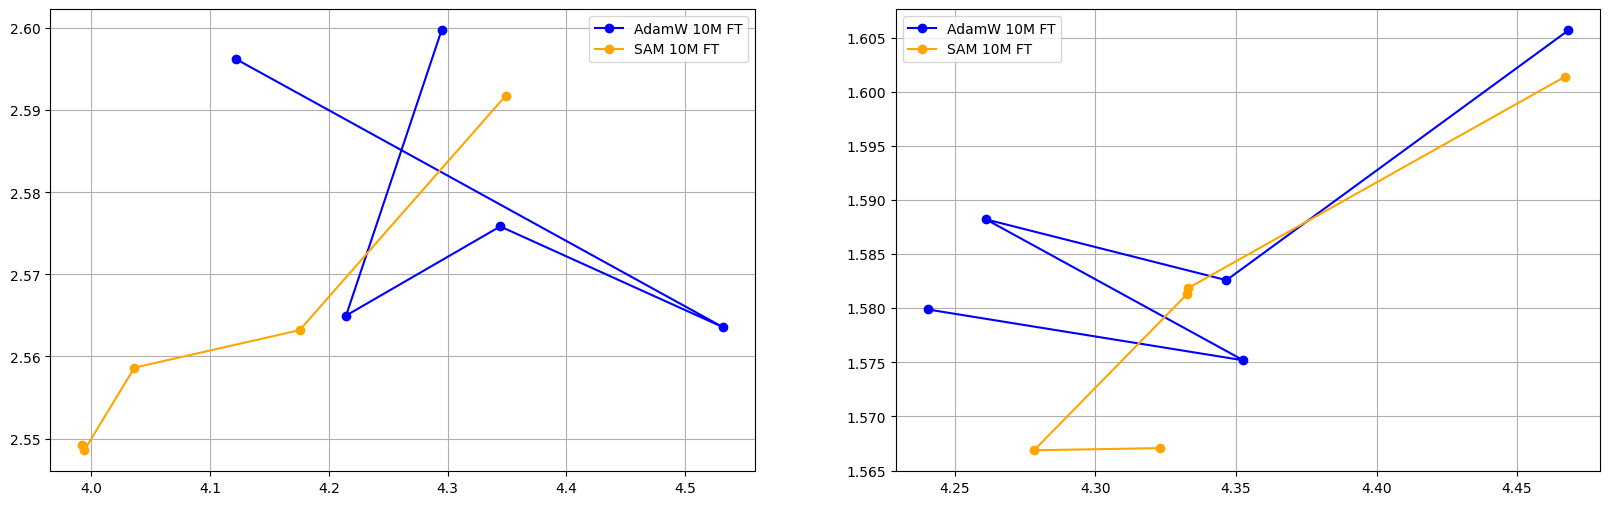

In [147]:
for size in [60]:
    # tokens_list = sorted(np.unique(list(CHECKPOINT_MAP[size].values())))

    fig, axs = plt.subplots(1, len(CPT_DATASET), figsize=(20, 6))

    # Ensure axs is always an array for single subplot case
    if len(CPT_DATASET) == 1:
        axs = [axs]

    markers = ["o", "v", "*"]
    colors = ["blue", "orange"]
    for col, cpt_dataset in enumerate(CPT_DATASET):
        ax = axs[col]
        for i, cpt_token in enumerate([10]):
            for j, optim in enumerate(OPTIM):
                run_info = get_run_info(size=size, optim=optim, cpt_dataset=cpt_dataset, cpt_tokens=cpt_token)
                if run_info is None:
                    continue

                cpt_lrs = sorted(run_info["cpt"].keys())
                best_results = {
                    "x" : [],
                    "pt" : [],
                    "cpt" : []
                }
                for t in tokens_list:
                    best_cpt_val = float('inf')
                    best_pt_val = float('inf')
                    best_x = None

                    for cpt_lr in cpt_lrs:
                        try:
                            cpt_val = run_info["cpt"][cpt_lr][t][cpt_dataset]
                            dclm_val = run_info["cpt"][cpt_lr][t]["dclm_val"]
                            x = run_info["cpt"][cpt_lr][t]["multiplier"]

                            if cpt_val <= best_cpt_val:
                                best_cpt_val = cpt_val
                                best_pt_val = dclm_val
                        except Exception as e:
                            continue
                    
                    best_results["x"].append(x/10)
                    best_results["cpt"].append(best_cpt_val)
                    best_results["pt"].append(best_pt_val)
                
                
                ax.plot(best_results["pt"], best_results["cpt"], label=OPTIM_MAP[optim] + f" {cpt_token}M FT", color=colors[j], marker=markers[i])

        ax.legend()
        ax.grid(True)
    plt.show()
   






## Perturbation

/mnt/tmp/2719300/ipykernel_2960465/1456186907.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(PERTURBATIONS[size]))


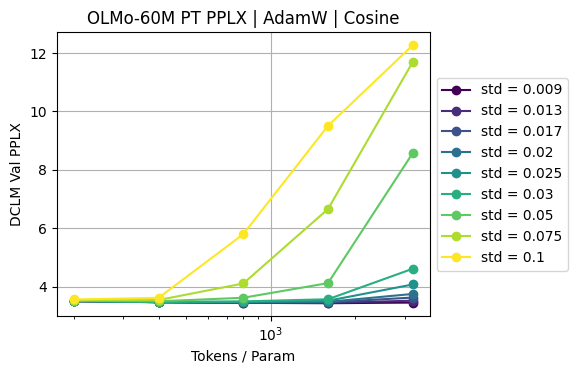

Missing Run: Optim AdamW | Token 48B | Size 60M
Missing Run: Optim AdamW | Token 24B | Size 60M


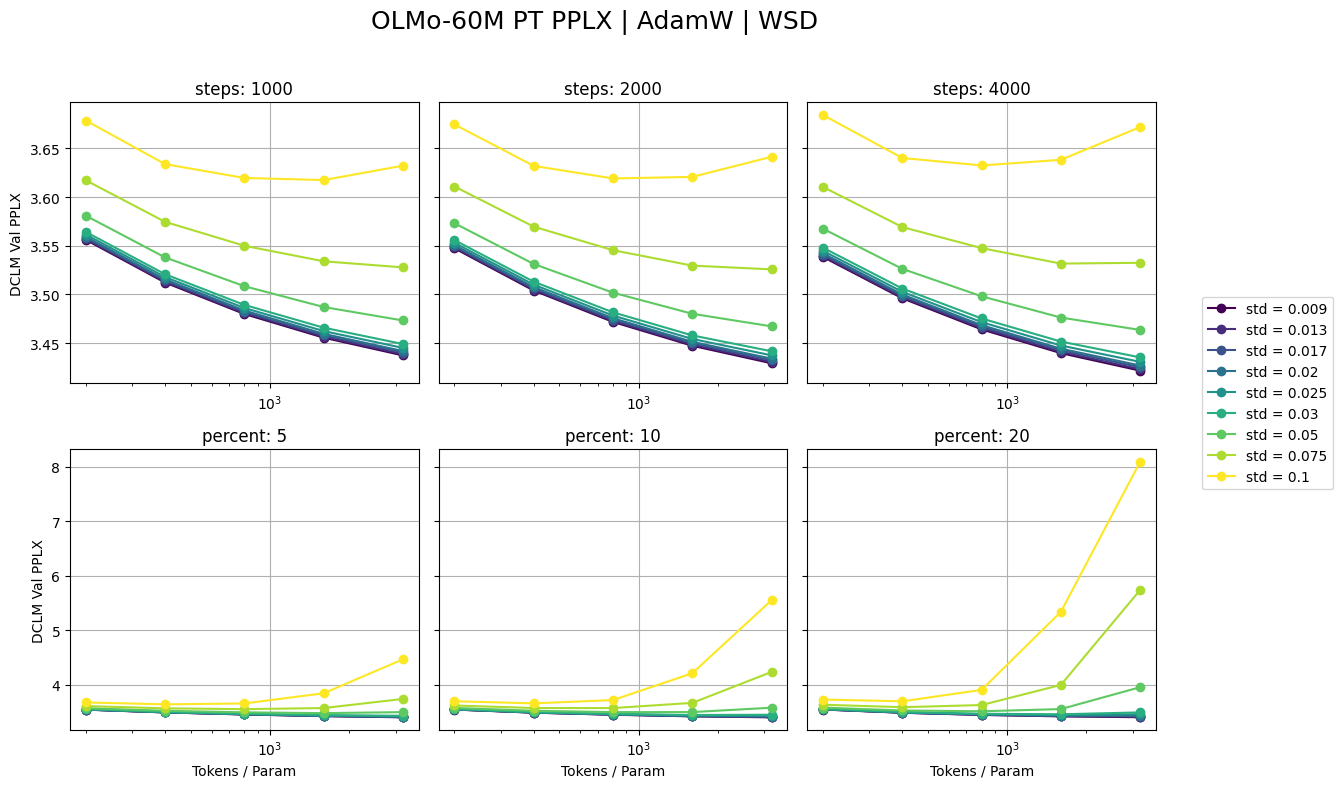

In [27]:
size=60
optim="adamw"

cmap = cm.get_cmap('viridis', len(PERTURBATIONS[size]))

for pt_lrs in ["cosine", "wsd"]:
    if pt_lrs == "cosine":
        plt.figure(figsize=(6,4))
        run_info = get_run_info(size, optim, perturb=True, anneal=False)
        for perturbation in PERTURBATIONS[size]:
            x = [r["multiplier"] for r in run_info["perturbed"][perturbation].values()]
            y = [r["dclm_perturbed"] for r in run_info["perturbed"][perturbation].values()]
            color_idx = PERTURBATIONS[size].index(perturbation)
            color = cmap(color_idx)
            line, = plt.plot(x, y, label=f"std = {perturbation}", color=color, marker='o')
        plt.grid()
        plt.xlabel("Tokens / Param")
        plt.ylabel("DCLM Val PPLX")
        plt.xscale('log')
        # Use only one legend for the entire figure; use the handles/labels from the first axis
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"OLMo-{size}M PT PPLX | {OPTIM_MAP[optim]} | Cosine")
        plt.tight_layout(rect=[0, 0, 0.98, 0.96])  # leave space for legend outside
        if SAVE:
            os.makedirs(os.path.join(results_dir, f"plots/perturbation"), exist_ok=True)
            plt.savefig(f"results/plots/perturbation/lrs_{size}m_cosine.png", bbox_inches="tight")
            plt.close()
        else:
            plt.show()
    elif pt_lrs == "wsd":
        fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharey='row')
        for jdx, anneal_type in enumerate(ANNEAL_CONFIG.keys()):
            for idx, val in enumerate(ANNEAL_CONFIG[anneal_type]):
                if anneal_type == "steps":
                    run_info = get_run_info(size, optim, anneal=True, anneal_steps=val, pt_lr=3e-4, perturb=True)
                else:
                    run_info = get_run_info(size, optim, anneal=True, anneal_percent=val, pt_lr=3e-4, perturb=True)
        
                handles_labels = [[], []]
                ax = axs[jdx][idx]
                for perturbation in PERTURBATIONS[size]:
                    x = [r["multiplier"] for r in run_info["perturbed"][perturbation].values()]
                    y = [r["dclm_perturbed"] for r in run_info["perturbed"][perturbation].values()]
                    color_idx = PERTURBATIONS[size].index(perturbation)
                    color = cmap(color_idx)
                    line, = ax.plot(x, y, label=f"std = {perturbation}", color=color, marker='o')
                ax.set_title(f"{anneal_type}: {val}")
                ax.grid()
                if jdx == 1:
                    ax.set_xlabel("Tokens / Param")
                if idx == 0:
                    ax.set_ylabel("DCLM Val PPLX")
                ax.set_xscale('log')
        # Use only one legend for the entire figure; use the handles/labels from the first axis
        handles, labels = axs[0][0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
        plt.suptitle(f"OLMo-{size}M PT PPLX | {OPTIM_MAP[optim]} | WSD", fontsize=18)
        plt.tight_layout(rect=[0, 0, 0.98, 0.96])  # leave space for legend outside
        if SAVE:
            os.makedirs(os.path.join(results_dir, f"plots/perturbation"), exist_ok=True)
            plt.savefig(f"results/plots/perturbation/lrs_{size}m_wsd.png", bbox_inches="tight")
            plt.close()
        else:
            plt.show()

/tmp/ipykernel_3916159/1710889956.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(PERTURBATIONS_SUB))


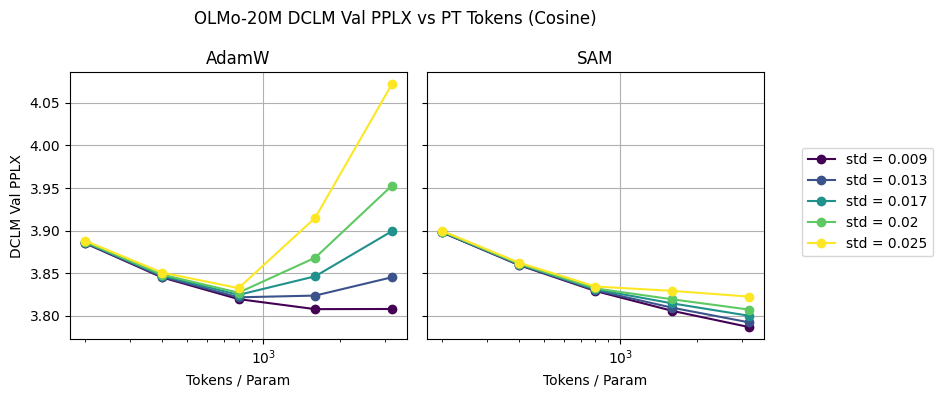

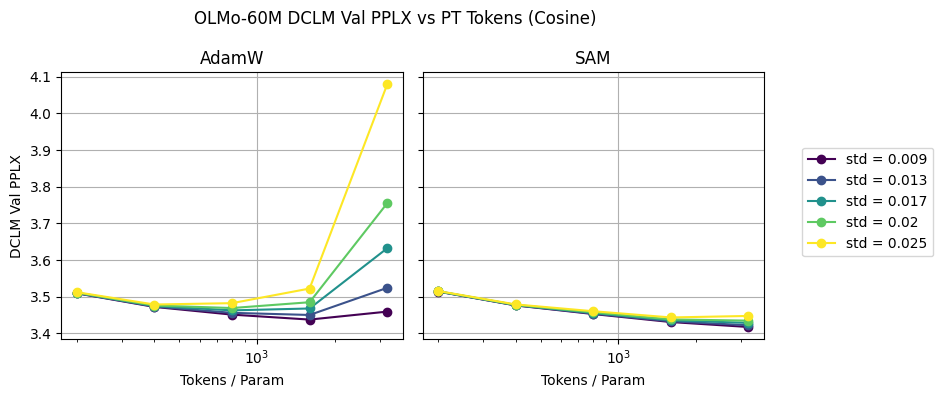

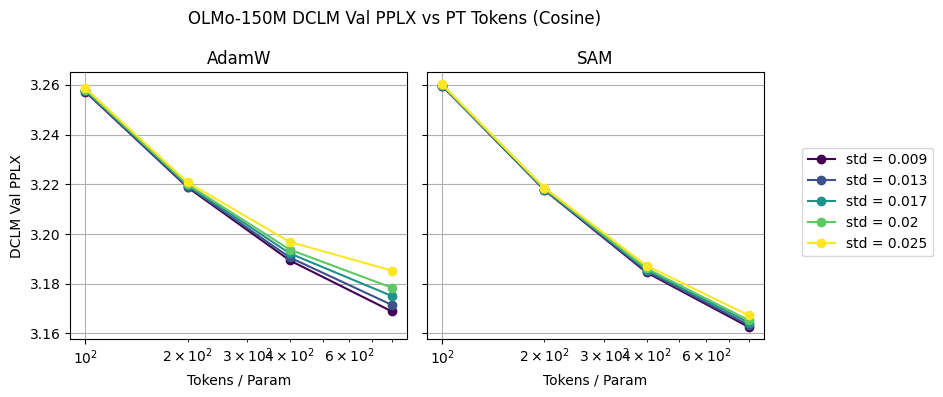

In [24]:
for size in SIZE:
    PERTURBATIONS_SUB = PERTURBATIONS[:-4]
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
    handles_labels = [[], []]
    for idx, optim in enumerate(OPTIM):
        run_info = get_run_info(size, optim, perturb=True, pt_lr="adapt", rho=5e-2)
        ax = axs[idx]
        for perturbation in PERTURBATIONS_SUB:
            

            # Get a viridis colormap with enough distinct colors for all PERTURBATIONS_SUB
            cmap = cm.get_cmap('viridis', len(PERTURBATIONS_SUB))
            color_idx = PERTURBATIONS_SUB.index(perturbation)
            color = cmap(color_idx)

            x = [r["multiplier"] for r in run_info["perturbed"][perturbation].values()]
            y = [r["dclm_perturbed"] for r in run_info["perturbed"][perturbation].values()]
            line, = ax.plot(x, y, label=f"std = {perturbation}", marker='o', color=color)
        ax.set_title(f"{OPTIM_MAP[optim]}")
        ax.grid()
        ax.set_xlabel("Tokens / Param")
        if idx == 0:
            ax.set_ylabel("DCLM Val PPLX")
        ax.set_xscale('log')
    # Use only one legend for the entire figure; use the handles/labels from the first axis
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.suptitle(f"OLMo-{size}M DCLM Val PPLX vs PT Tokens (Cosine)")
    plt.tight_layout(rect=[0, 0, 0.98, 1])  # leave space for legend outside
    if SAVE:
        os.makedirs(os.path.join(results_dir, f"plots/perturbation"), exist_ok=True)
        plt.savefig(f"results/plots/perturbation/optim_{size}m_cosine.png", bbox_inches="tight")
        plt.close()
    else:
        plt.show()

## Quantization

In [34]:
bits = [4, 8]
model_type = ["olmo", "hf"]
SIZE = [20, 60]

### Check Model Conversion

[3.884697468398429, 3.8441834750209267, 3.817461964983246, 3.7938253074975687, 3.775120679223931]
[3.8846974674254815, 3.8441834737440286, 3.8174619638667235, 3.793825306112226, 3.7751206785167493]
[3.8975258873950804, 3.859160263242175, 3.8282639669837506, 3.8023925579781146, 3.7817063897639236]
[3.89752588642977, 3.859160262786249, 3.828263965097424, 3.8023925561307363, 3.781706386412066]


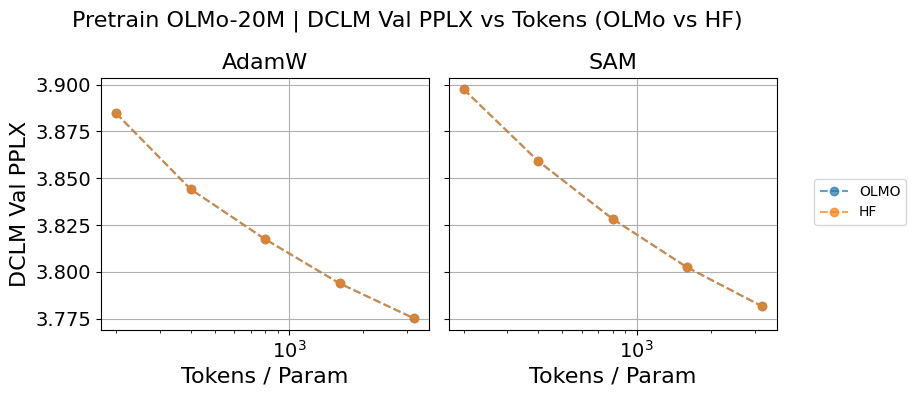

[3.5087635456770196, 3.47129911114883, 3.446604618976806, 3.4262859080904735, 3.409790851840575]
[3.5087635435894593, 3.47129911370759, 3.446604622728076, 3.4262859060517896, 3.4097908548659532]
[3.5137910119309277, 3.475834514935671, 3.451591238395329, 3.4290662967613, 3.413087848787294]
[3.5137910119183267, 3.4758345152564227, 3.4515912385394762, 3.429066296434057, 3.413087850167673]


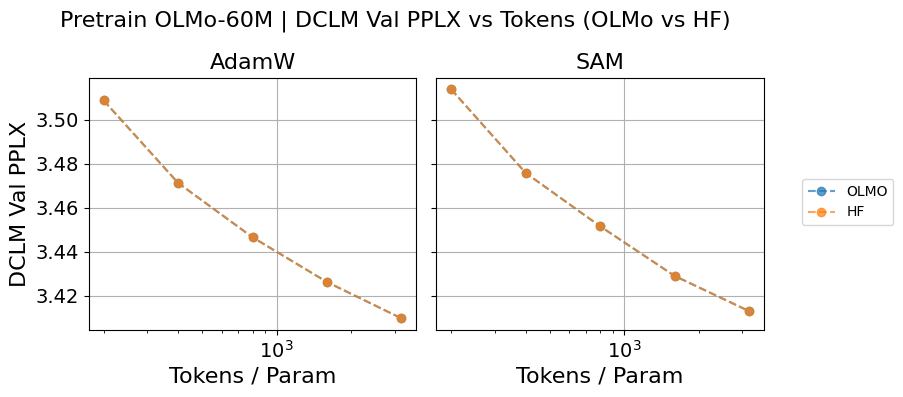

In [35]:
for size in SIZE:
    fig, axs = plt.subplots(1, len(OPTIM), figsize=(4 * len(OPTIM), 4), sharex=True, sharey=True)
    lines = []
    labels = []
    for idx, optim in enumerate(OPTIM):
        ax = axs[idx]
        for m in model_type:
            run_info = get_run_info(size, optim, model_type=m)
            if run_info is None:
                continue
            x = [r["multiplier"] for r in run_info["pretrain"].values()]
           
            y = [r["dclm"] for r in run_info["pretrain"].values()]
            print(y)
            # plot and capture the handle/label for legend
            line, = ax.plot(
                x, y,
                marker="o",
                label=m.upper(),
                alpha=0.7,
                linestyle='--'
            )
            if idx == 0:
                lines.append(line)
                labels.append(m.upper())
        ax.set_title(f"{OPTIM_MAP[optim]}", fontsize=TITLE_FONTSIZE)
        ax.grid(True)
        if idx == 0:
            ax.set_ylabel("DCLM Val PPLX", fontsize=AXIS_FONTSIZE)
        else:
            ax.set_ylabel("")
        ax.set_yscale('linear')
        ax.tick_params(labelsize=TICKS_FONTSIZE)
        ax.set_xlabel("Tokens / Param", fontsize=AXIS_FONTSIZE)
        ax.set_xscale('log')
    
    # Only one legend for the whole figure
    fig.legend(lines, labels, loc='center left', bbox_to_anchor=(1, 0.5))
    fig.suptitle(f"Pretrain OLMo-{size}M | DCLM Val PPLX vs Tokens (OLMo vs HF)", fontsize=TITLE_FONTSIZE)
    plt.tight_layout(rect=[0, 0, 0.98, 1])
    # if SAVE:
    #     os.makedirs(os.path.join(results_dir, "plots/pretrain"), exist_ok=True)
    #     plt.savefig(os.path.join(results_dir, f"plots/pretrain/optim_{size}m_pt_pplx.png"), bbox_inches='tight')
    #     plt.close()
    # else:
    plt.show()

In [102]:
for row_idx, size in enumerate(SIZE):
    fig, axs = plt.subplots(1, len(OPTIM), figsize=(4 * len(OPTIM), 4), sharex="row", sharey="row")
    if len(OPTIM) == 1:
        axs = np.array([axs])
    lines = []
    labels = []
    for col_idx, optim in enumerate(OPTIM):
        ax = axs[col_idx]
        run_info = get_run_info(size, optim, model_type="hf", quantized=True)

        # Baseline plot
        x = [r["multiplier"] for r in run_info["pretrain"].values()]
        y = [r["dclm"] for r in run_info["pretrain"].values()]
        line, = ax.plot(
            x, y,
            marker="o",
            label="Baseline",
            linestyle='--',
            color="black"
        )
        if col_idx == 0:
            lines.append(line)
            labels.append("Baseline")

        # INT4 and INT8 quantization
        for bit in [4, 8]:
            q_run_info = run_info["quantized"].get(bit)
            if q_run_info is None:
                continue
            x_q = [r["multiplier"] for r in q_run_info.values()]
            y_q = [r["dclm_quant"] for r in q_run_info.values()]
            line, = ax.plot(
                x_q, y_q,
                marker="o",
                label=f"INT{bit}"
            )
            if col_idx == 0:
                lines.append(line)
                labels.append(f"INT{bit}")

        ax.set_title(f"{OPTIM_MAP[optim]}", fontsize=TITLE_FONTSIZE)
        ax.grid(True)
        if col_idx == 0:
            ax.set_ylabel(f"DCLM Val PPLX", fontsize=AXIS_FONTSIZE)
        else:
            ax.set_ylabel("")
        ax.set_yscale('linear')
        ax.tick_params(labelsize=TICKS_FONTSIZE)
        ax.set_xlabel("Tokens / Param", fontsize=AXIS_FONTSIZE)
        ax.set_xscale('log')

    # Row-wise title at the top, centered across the columns
    plt.suptitle(f"OLMo-{size}M", fontsize=TITLE_FONTSIZE, fontweight='bold', y=1)
    # Move legend to the right outside the plot
    fig.legend(lines, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=AXIS_FONTSIZE)
    fig.suptitle(f"OLMo-{size}M | DCLM Val PPLX vs Tokens (Quantized)", fontsize=TITLE_FONTSIZE, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 1])  # Shrink plot so legend doesn't overlap
    if True:
        os.makedirs(os.path.join(results_dir, "plots/quantization"), exist_ok=True)
        plt.savefig(os.path.join(results_dir, f"plots/quantization/optim_{size}m_pt_pplx.png"), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [ ]:

api = wandb.Api(timeout=240)
run = api.run("/iwatts-carnegie-mellon-university/large-scale-experiments/runs/OLMo-20m-tk300B-adamw-lr3e-4-wd1e-1-bs256-anneal-ckpt15000")

In [ ]:
LRS = dict()

In [ ]:
from tqdm import tqdm

In [ ]:
for ckpt in tqdm(CHECKPOINT_MAP.keys()):
    run_name = f"/iwatts-carnegie-mellon-university/large-scale-experiments/runs/OLMo-20m-tk300B-adamw-lr3e-4-wd1e-1-bs256-anneal-ckpt{ckpt}"
    run = api.run(run_name)

    LRS[ckpt] = run.history(keys=["optim/learning_rate_group0"])

100%|██████████| 7/7 [00:03<00:00,  2.06it/s]


In [ ]:
run_name = f"/iwatts-carnegie-mellon-university/large-scale-experiments/runs/OLMo-20m-tk300B-adamw-lr3e-4-wd1e-1-bs256"
run = api.run(run_name)

LRS[0] = run.history(keys=["optim/learning_rate_group0"])

In [ ]:
LRS[0]

,_step,optim/learning_rate_group0
0,981.0,0.000294
1,7329.0,0.000300
2,8502.0,0.000300
3,10628.0,0.000300
4,20921.0,0.000300
...,...,...
495,1131347.0,0.000300
496,1134265.0,0.000300
497,1137977.0,0.000300
498,1139153.0,0.000300


In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for ckpt in sorted((LRS.keys())):
    # if ckpt > 500000:
    #     continue
    df = LRS[ckpt]
    steps = df["_step"] + ckpt  # shift the steps by the checkpoint value
    lrs = df["optim/learning_rate_group0"]
    
    if ckpt == 0:
        label = "300B"
        # For the 0 checkpoint, prepend a 0-step with a learning rate of 0
        # Ensure proper type so .insert() works (e.g., df["_step"] could be a Series)
        steps = steps.tolist()
        lrs = lrs.tolist()
        steps.insert(0, 0)
        lrs.insert(0, 0)
    else:
        label = f"{CHECKPOINT_MAP[ckpt]}B"

    plt.plot(steps, lrs, label=label)

plt.xlabel("Global Step")
plt.ylabel("Learning Rate")
plt.title("WSD LR Scheduler")
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.savefig("results/wsd_lrs_20m")
plt.show()

NameError: name 'LRS' is not defined

<Figure size 1000x500 with 0 Axes>

## Scaling Law

In [18]:
loss_info = {
    150: {
        100 : {
            3e-3: 3.27483,
            1e-3: 3.25711,
            6e-4: 3.26833,
            3e-4: 3.30244,
        },
        200: {
            3e-3: 3.25531,
            1e-3: 3.21863,
        },
        400: {
            6e-4: 3.18851,
        },
        800: {
            6e-4: 3.16666,
        },
    },
    60: {
        200: {
            3e-3: 3.51528,
            1e-3: 3.50888,
            6e-4: 3.52541 
        },
        400: {
            6e-4: 3.4778,
            1e-3: 3.47145,
        },
        800: {
            1e-3: 3.44897,
            3e-4: 3.4601,
            6e-4: 3.44676,
        },
        1600: {
            3e-4: 3.43207,
            6e-4: 3.42647,
        },
        3200: {
            3e-4: 3.41001
        },
    },
    20: {
        200: {
            1e-2: 3.89652,
            3e-3: 3.88484,
            1e-3: 3.93096,
        },
        400: {
            3e-3: 3.84433,
            1e-3: 3.87037,
        },
        800: {
            3e-3: 3.81761,
            1e-3: 3.82749,
        },
        1600: {
            3e-3: 3.80098,
            1e-3: 3.79403,
            6e-4: 3.80239
        },
        3200: {
            1e-3: 3.77533,
            6e-4: 3.77741
        },
    }
}


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os

# loss_info is a nested dict of:
# {model_size: {dn_ratio: {lr: val_loss, ...}, ...}, ...}
# We'll plot, for each model size, curves of val loss vs LR for each D/N ratio.

sizes_to_plot = [20, 60, 150]
fig, axs = plt.subplots(1, len(sizes_to_plot), figsize=(21, 5))

for idx, size in enumerate(sizes_to_plot):
    ax = axs[idx]
    size_dict = loss_info[size]  # {dn_ratio: {lr: loss, ...}, ...}

    # Gather all D/N ratios for the current size
    dn_ratios = sorted(size_dict.keys())

    # For each D/N ratio, plot loss vs LR
    for dn in dn_ratios:
        lr_loss_dict = size_dict[dn]
        lrs = sorted(lr_loss_dict.keys())
        losses = [lr_loss_dict[lr] for lr in lrs]
        # plot the curve
        ax.plot(lrs, losses, marker='o', label=f"D/N={dn}")

        # mark minimum point with black star
        min_idx = np.argmin(losses)
        min_lr = lrs[min_idx]
        min_loss = losses[min_idx]
        ax.plot(min_lr, min_loss, marker="*", color="k", ms=14, label=None, zorder=10)

    ax.set_title(f"Model Size {size}M")
    ax.set_xscale("log")
    ax.set_xlabel("Learning Rate")
    if idx == 0:
        ax.set_ylabel("Validation Loss")
    ax.legend(title="D/N", loc="best")
    ax.grid(True)

plt.tight_layout()

if True:
    os.makedirs("results/plots/scaling_law", exist_ok=True)
    plt.savefig("results/plots/scaling_law/loss_lr.png")
    plt.close()
else:
    plt.show()


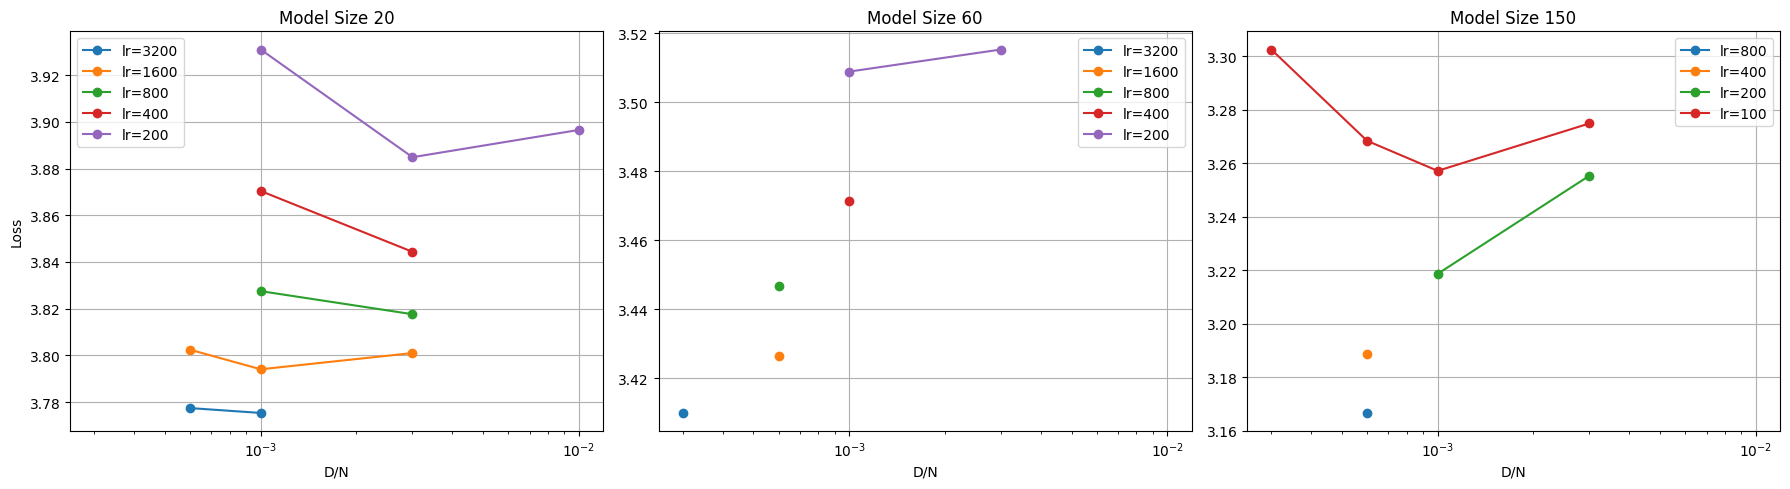

In [7]:
import matplotlib.pyplot as plt

# Gather the sizes to plot, in the specified order
sizes_to_plot = [20, 60, 150]

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey="col", sharex=True)

for idx, size in enumerate(sizes_to_plot):
    ax = axs[idx]
    size_dict = loss_info[size]
    for lr in sorted(size_dict.keys(), reverse=True):
        inner = size_dict[lr]
        # inner is a dict with step: value
        steps = sorted(inner.keys())
        values = [inner[step] for step in steps]
        ax.plot(steps, values, marker='o', label=f'lr={lr}')
    ax.set_title(f'Model Size {size}')
    ax.set_xlabel('D/N')
    ax.set_xscale('log')
    if idx == 0:
        ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()